# **TRABAJO FIN DE MÁSTER**

### **Clasificación automática de tickets de soporte mediante NLP y Machine Learning: predicción de Type, Priority y Queue con un sistema de confianza AUTO / REVIEW / MANUAL**

# 1. Librerías y cargar BD

### **Entorno de ejecución: Cambiar tipo de entorno de ejecución a GPU**

In [1]:
import torch

print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU disponible: True
GPU: Tesla T4


### Librerías

In [2]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn wordcloud joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

### Carga BD

In [3]:
from google.colab import files
uplodaded = files.upload()      # tickets.csv guardados de Kaggle

Saving tickets.csv to tickets.csv


In [4]:
import pandas as pd
df = pd.read_csv("tickets.csv")

In [5]:
import os
print(os.listdir("/content"))

['.config', 'tickets.csv', 'sample_data']


In [6]:
# display(df.sample(2, random_state=42))

# 2.2. EDA

## 2.1. Estrucutra y calidad del dataset

### Tamaño del dataset

In [7]:
filas, columnas = df.shape
print(f"Filas: {filas:,}, Columnas: {columnas:,}")

Filas: 28,587, Columnas: 16


### Información de las variables utilizadas en el EDA

In [8]:
excluded_columns = ["answer", "version"]
df_eda = df.drop(columns=excluded_columns).copy()

In [9]:
# tipo de dato, número de valores únicos, NA, %NAs.
# (los valores únicos nos permiten qué variables categóricas tenemos y su cardinalidad)
variables_info = pd.DataFrame({
    "Tipo": df_eda.dtypes.astype(str),
    "Valores únicos": [df_eda[col].nunique(dropna=True) for col in df_eda.columns],
    "Valores nulos": df_eda.isna().sum(),
    "% nulos": (df_eda.isna().mean() * 100).round(2)
})

display(variables_info)

,Tipo,Valores únicos,Valores nulos,% nulos
subject,object,24749,3838,13.43
body,object,28587,0,0.00
type,object,4,0,0.00
queue,object,10,0,0.00
priority,object,3,0,0.00
language,object,2,0,0.00
tag_1,object,116,0,0.00
tag_2,object,256,13,0.05
tag_3,object,392,136,0.48
tag_4,object,554,3058,10.70


### Registros dupliados

In [10]:
print(f"Registros duplicados: {df_eda.duplicated().sum():,}")

Registros duplicados: 0


### Posibles inconsistencias

**Diferencias de mayúsculas/minúsculas y espacios:**

Se comprueba si existen categorías que, tras normalizar espacios y mayúsculas/minúsculas, podrían corresponder al mismo valor.

In [11]:
import pandas as pd

resultados = []

categorical_cols = df_eda.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in categorical_cols:
    serie = df_eda[col].dropna().astype(str)

    # Normalización
    normalizada = serie.str.strip().str.lower()

    # Valores únicos antes y después
    unicos_originales = serie.nunique()
    unicos_normalizados = normalizada.nunique()

    # Valores únicos que se fusionan
    valores_fusionados = unicos_originales - unicos_normalizados

    # Identificar valores normalizados que agrupan
    # más de un valor original
    tabla = pd.DataFrame({
        "original": serie,
        "normalizado": normalizada
    })

    duplicados = (
        tabla.groupby("normalizado")["original"]
        .nunique()
    )

    valores_fusionados_normalizados = duplicados[
        duplicados > 1
    ].index

    # Filas pertenecientes a valores fusionados
    filas_afectadas = normalizada.isin(
        valores_fusionados_normalizados
    ).sum()

    porcentaje_afectado = (
        filas_afectadas / len(serie) * 100
    )

    resultados.append({
        "Variable": col,
        "Valores únicos originales": unicos_originales,
        "Valores únicos normalizados": unicos_normalizados,
        "Valores únicos fusionados": valores_fusionados,
        "Filas afectadas": filas_afectadas,
        "% filas afectadas": round(porcentaje_afectado, 2)
    })

# Crear tabla final
resultados_df = pd.DataFrame(resultados)

# Mostrar sin índice
display(
    resultados_df.style
    .format({"% filas afectadas": "{:.2f}"})
    .hide(axis="index")
)


Variable,Valores únicos originales,Valores únicos normalizados,Valores únicos fusionados,Filas afectadas,% filas afectadas
subject,24749,24620,129,258,1.04
body,28587,28572,15,28,0.10
type,4,4,0,0,0.00
queue,10,10,0,0,0.00
priority,3,3,0,0,0.00
language,2,2,0,0,0.00
tag_1,116,115,1,3,0.01
tag_2,256,255,1,147,0.51
tag_3,392,391,1,39,0.14
tag_4,554,551,3,52,0.20


In [12]:
# POSIBLES INCONSISTENCIAS"

categorical_cols = df_eda.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in categorical_cols:
    serie = df_eda[col].dropna().astype(str)

    valores_originales = set(serie.unique())
    valores_normalizados = set(serie.str.strip().str.lower().unique())

    if len(valores_originales) != len(valores_normalizados):
        print(f"(!!) {col}: posibles diferencias de espacios/mayúsculas")
        print(f"   Valores únicos originales: {len(valores_originales)}")
        print(f"   Valores únicos normalizados: {len(valores_normalizados)}")
    else:
        print(f"(OK) {col}: no se detectan inconsistencias básicas")

(!!) subject: posibles diferencias de espacios/mayúsculas
   Valores únicos originales: 24749
   Valores únicos normalizados: 24620
(!!) body: posibles diferencias de espacios/mayúsculas
   Valores únicos originales: 28587
   Valores únicos normalizados: 28572
(OK) type: no se detectan inconsistencias básicas
(OK) queue: no se detectan inconsistencias básicas
(OK) priority: no se detectan inconsistencias básicas
(OK) language: no se detectan inconsistencias básicas
(!!) tag_1: posibles diferencias de espacios/mayúsculas
   Valores únicos originales: 116
   Valores únicos normalizados: 115
(!!) tag_2: posibles diferencias de espacios/mayúsculas
   Valores únicos originales: 256
   Valores únicos normalizados: 255
(!!) tag_3: posibles diferencias de espacios/mayúsculas
   Valores únicos originales: 392
   Valores únicos normalizados: 391
(!!) tag_4: posibles diferencias de espacios/mayúsculas
   Valores únicos originales: 554
   Valores únicos normalizados: 551
(!!) tag_5: posibles difer

### Analisis del idioma

**Distribución de language**

Aquí sí mantenemos los NaN, porque en este caso queremos saber también si existen tickets cuyo idioma no está informado.

In [13]:
language_counts = df_eda["language"].value_counts(dropna=False)
language_pct = (language_counts / len(df_eda) * 100).round(2)

language_summary = pd.DataFrame({
    "Frecuencia": language_counts,
    "Porcentaje (%)": language_pct
})

display(language_summary)

,Frecuencia,Porcentaje (%)
language,,
en,16338,57.15
de,12249,42.85


Porcentaje de tickets en inglés

In [14]:
english_count = (df["language"].str.lower() == "en").sum()
english_pct = english_count / len(df) * 100

print(f"Tickets en inglés: {english_count:,}")
print(f"Porcentaje del dataset: {english_pct:.2f}%")

Tickets en inglés: 16,338
Porcentaje del dataset: 57.15%


**Representación gráfica**

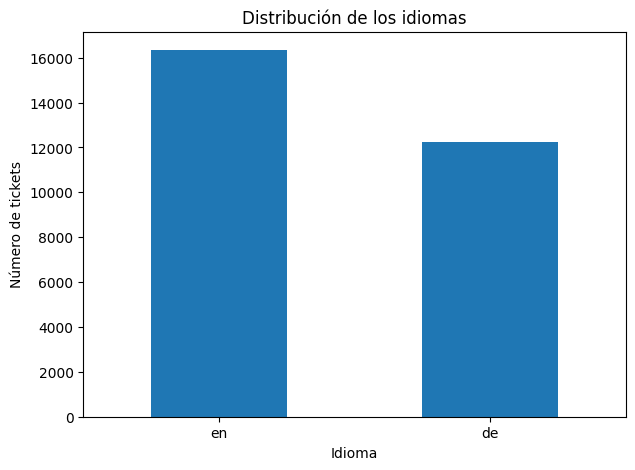

In [15]:
plt.figure(figsize=(7, 5))

language_counts.plot(kind="bar")

plt.title("Distribución de los idiomas")
plt.xlabel("Idioma")
plt.ylabel("Número de tickets")
plt.xticks(rotation=0)

plt.show()

In [16]:
# Filtrar únicamente los tickets en inglés
df_eda = df_eda[df_eda["language"] == "en"].copy()

print(f"Registros tras seleccionar inglés: {len(df_eda):,}")

Registros tras seleccionar inglés: 16,338


## 2.2. Variables de entrada (Subject, Body, Tags)


### Subject y Body

**Posibles inconsistencias: textos vacíos en "subject" y "body"**

In [17]:
text_cols = ["subject", "body"]

for col in text_cols:
    non_null = df_eda[col].dropna()
    empty = non_null.astype(str).str.strip().eq("").sum()
    percentage = empty / len(non_null) * 100

    print(f"{col}: {empty:,} valores vacíos entre los no nulos ({percentage:.2f}%)")

subject: 0 valores vacíos entre los no nulos (0.00%)
body: 0 valores vacíos entre los no nulos (0.00%)


**Elementos potencialmente irrelevantes presentes en el texto**

Vamos a comprobar: URLs y HTML. Para saber qué limpieza puede ser necesaria posteriormente en el Preprocesamiento.

In [18]:
import re

patterns = {
    "URLs": r"https?://\S+|www\.\S+",
    "HTML": r"<[^>]+>"
}

for col in text_cols:

    print(f"{col.upper()}")

    text = df_eda[col].fillna("").astype(str)

    for name, pattern in patterns.items():

        count = text.str.contains(
            pattern,
            regex=True,
            na=False
        ).sum()

        percentage = count / len(df_eda) * 100

        print(f"{name}: {count:,} ({percentage:.2f}%)")

SUBJECT
URLs: 0 (0.00%)
HTML: 0 (0.00%)
BODY
URLs: 0 (0.00%)
HTML: 520 (3.18%)


In [19]:
import re

patterns = {
    "URLs": r"https?://\S+|www\.\S+",
    "HTML": r"<[^>]+>"
}

for col in text_cols:

    print(f"{col.upper()}")

    text = df_eda[col].fillna("").astype(str)

    for name, pattern in patterns.items():

        count = text.str.contains(
            pattern,
            regex=True,
            na=False
        ).sum()

        percentage = count / len(df_eda) * 100

        print(f"{name}: {count:,} ({percentage:.2f}%)")

SUBJECT
URLs: 0 (0.00%)
HTML: 0 (0.00%)
BODY
URLs: 0 (0.00%)
HTML: 520 (3.18%)


**Longitud de los textos**
- Mediana/media de palabras y caracteres.
- Distribución mediante histogramas: esto nos permitirá ver si, por ejemplo, Body presenta una distribución muy dispersa o contiene muchos textos extremadamente largos.

In [20]:
text_cols = ["subject", "body"]

for col in text_cols:
    serie = df_eda[col].dropna().astype(str)

    df_eda.loc[serie.index, f"{col}_words"] = (
        serie.str.split().str.len()
    )

    df_eda.loc[serie.index, f"{col}_chars"] = (
        serie.str.len()
    )

    print(f"\n{col.upper()}")
    print(f"Mediana de palabras: {df_eda[f'{col}_words'].median():.0f}")
    print(f"Media de palabras:   {df_eda[f'{col}_words'].mean():.1f}")
    print(f"Mediana de caracteres: {df_eda[f'{col}_chars'].median():.0f}")
    print(f"Media de caracteres:   {df_eda[f'{col}_chars'].mean():.1f}")


SUBJECT
Mediana de palabras: 5
Media de palabras:   5.7
Mediana de caracteres: 42
Media de caracteres:   43.6

BODY
Mediana de palabras: 55
Media de palabras:   53.9
Mediana de caracteres: 377
Media de caracteres:   367.9


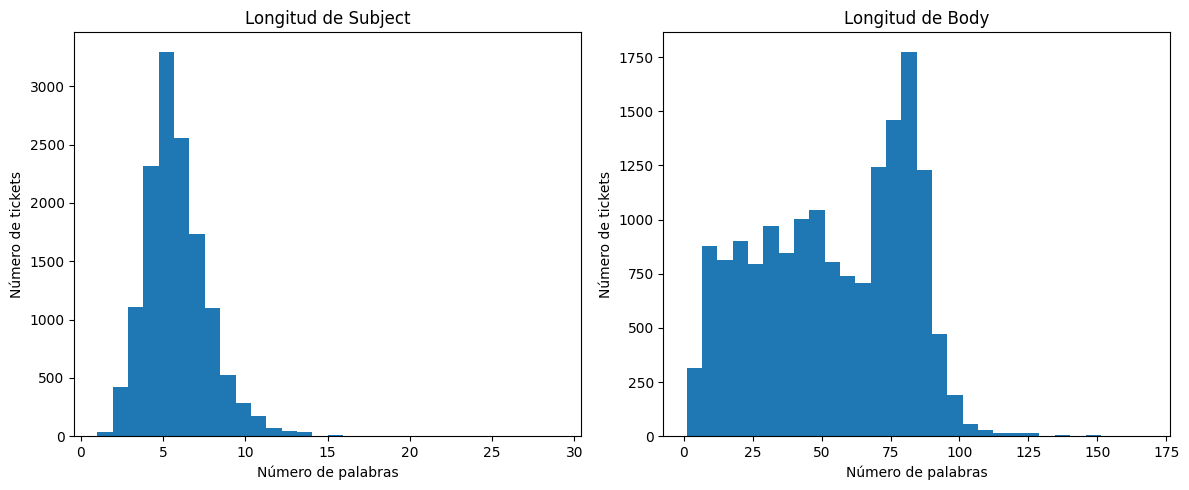

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_eda["subject_words"].plot(
    kind="hist",
    bins=30,
    ax=axes[0]
)

axes[0].set_title("Longitud de Subject")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Número de tickets")

df_eda["body_words"].plot(
    kind="hist",
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Longitud de Body")
axes[1].set_xlabel("Número de palabras")
axes[1].set_ylabel("Número de tickets")

plt.tight_layout()
plt.show()

In [22]:
# Análisis de valores extremos en la longitud de los textos

text_lengths = {
    "Subject - palabras": "subject_words",
    "Subject - caracteres": "subject_chars",
    "Body - palabras": "body_words",
    "Body - caracteres": "body_chars"
}

for nombre, columna in text_lengths.items():

    serie = df_eda[columna]

    percentiles = serie.quantile(
        [0.50, 0.90, 0.95, 0.99]
    )

    print(f"\n{nombre.upper()}")

    print(f"Mediana (P50): {percentiles[0.50]:.0f}")
    print(f"P90:           {percentiles[0.90]:.0f}")
    print(f"P95:           {percentiles[0.95]:.0f}")
    print(f"P99:           {percentiles[0.99]:.0f}")
    print(f"Máximo:        {serie.max():.0f}")


SUBJECT - PALABRAS
Mediana (P50): 5
P90:           8
P95:           9
P99:           12
Máximo:        29

SUBJECT - CARACTERES
Mediana (P50): 42
P90:           63
P95:           71
P99:           90
Máximo:        234

BODY - PALABRAS
Mediana (P50): 55
P90:           86
P95:           90
P99:           101
Máximo:        168

BODY - CARACTERES
Mediana (P50): 377
P90:           580
P95:           604
P99:           668
Máximo:        1147


### Tags 1-8

**Crear Tags (unir etiquetas tag_1 - tag_8), donde cada ticket no tenga etiquetas duplicadas.**

In [23]:
# Comprobación de etiquetas duplicadas dentro de un mismo ticket

# Columnas originales de etiquetas
tag_cols = [f"tag_{i}" for i in range(1, 9)]

# 1. Pasar las etiquetas a formato largo
tags_long_raw = (
    df_eda[tag_cols]
    .assign(ticket_id=df_eda.index)
    .melt(
        id_vars="ticket_id",
        value_vars=tag_cols,
        var_name="tag_column",
        value_name="tag"
    )
)

# Eliminar valores ausentes
tags_long_raw = tags_long_raw.dropna(subset=["tag"])

# Normalizar espacios
tags_long_raw["tag"] = (
    tags_long_raw["tag"]
    .astype(str)
    .str.strip()
)

# 2. Identificar etiquetas duplicadas dentro de cada ticket
duplicados = tags_long_raw[
    tags_long_raw.duplicated(
        subset=["ticket_id", "tag"],
        keep=False
    )
]

# 3. Número de tickets con etiquetas duplicadas
tickets_con_duplicados = duplicados["ticket_id"].nunique()

porcentaje_tickets = (
    tickets_con_duplicados / len(df_eda) * 100
)


# 4. Número de etiquetas diferentes que se repiten
etiquetas_duplicadas = duplicados["tag"].nunique()

# 5. Mostrar resultados
print("Duplicados de etiquetas dentro del mismo ticket")

print(
    f"Tickets con etiquetas duplicadas: "
    f"{tickets_con_duplicados:,} "
    f"({porcentaje_tickets:.2f}%)"
)

print(
    f"Etiquetas diferentes que aparecen duplicadas: "
    f"{etiquetas_duplicadas:,}"
)

# 6. e.g.

if tickets_con_duplicados > 0:

    ejemplo_ticket = duplicados["ticket_id"].iloc[0]

    print("\ne.g. ticket con etiqueta duplicada")
    print(f"Ticket: {ejemplo_ticket}")

    display(
        df_eda.loc[
            ejemplo_ticket,
            tag_cols
        ].to_frame().T
    )

# 7. Eliminar duplicados dentro de cada ticket
tags_long = tags_long_raw.drop_duplicates(
    subset=["ticket_id", "tag"]
)

# 8. Crear la variable Tags sin duplicados dentro de cada ticket
tags_por_ticket = (
    tags_long
    .groupby("ticket_id")["tag"]
    .apply(list)
)

df_eda["Tags"] = (
    df_eda.index
    .map(tags_por_ticket)
    .to_series(index=df_eda.index)
    .apply(lambda x: x if isinstance(x, list) else [])
)

Duplicados de etiquetas dentro del mismo ticket
Tickets con etiquetas duplicadas: 9 (0.06%)
Etiquetas diferentes que aparecen duplicadas: 4

e.g. ticket con etiqueta duplicada
Ticket: 135


,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
135,Printer,Hardware,Issue,Support,Printer,Document,Connection,Ink


**Frecuencia de todas las etiquetas (sin duplicados)**

In [24]:
from collections import Counter

# Unir todas las etiquetas de todos los tickets
all_tags = [
    tag
    for tags in df_eda["Tags"]
    for tag in tags
]

# Frecuencia de cada etiqueta
# Como los duplicados dentro de cada ticket ya se han eliminado,
# la frecuencia corresponde al número de tickets en los que aparece
tag_frequencies = (
    pd.Series(Counter(all_tags))
    .sort_values(ascending=False)
)

# Número total de tickets
print(f"Número total de tickets: {len(df_eda):,}")

# Número total de etiquetas diferentes
print(
    f"Número total de etiquetas diferentes: "
    f"{len(tag_frequencies):,}"
)

# Número total de apariciones de etiquetas
print(
    f"Número total de apariciones de etiquetas: "
    f"{len(all_tags):,}"
)

Número total de tickets: 16,338
Número total de etiquetas diferentes: 886
Número total de apariciones de etiquetas: 76,758


**Distribución de la frecuencia de las etiquetas**

Tabla: nos muestra cómo se distribuye la frecuencia de las 1.254 etiquetas.

Gráfico: se centra únicamente en las cinco alternativas de umbral que vamos a llevar al modelado.

In [25]:
# Intervalos de frecuencia (N.º de tickets por etiqueta)
bins = [
    0, 1, 5, 10, 20, 50, 100,
    200, 500, 1000, float("inf")
]

labels = [
    "1",
    "2–5",
    "6–10",
    "11–20",
    "21–50",
    "51–100",
    "101–200",
    "201–500",
    "501–1.000",
    ">1.000"
]

# Asignar cada etiqueta a un intervalo según su frecuencia
frecuencia_intervalos = pd.cut(
    tag_frequencies,
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Número de etiquetas diferentes en cada intervalo
distribucion = frecuencia_intervalos.value_counts(
    sort=False
)

# Crear tabla
resultado = pd.DataFrame({
    "N.º tickets / etiqueta": distribucion.index.astype(str),
    "N.º etiquetas diferentes": distribucion.values
}).reset_index(drop=True)


# Número acumulado según los diferentes umbrales
umbrales = {
    "Etiquetas ≥ 51": [
        "51–100",
        "101–200",
        "201–500",
        "501–1.000",
        ">1.000"
    ],

    "Etiquetas ≥ 101": [
        "101–200",
        "201–500",
        "501–1.000",
        ">1.000"
    ],

    "Etiquetas ≥ 201": [
        "201–500",
        "501–1.000",
        ">1.000"
    ],

    "Etiquetas ≥ 501": [
        "501–1.000",
        ">1.000"
    ],

    "Etiquetas > 1.000": [
        ">1.000"
    ]
}

# Crear las columnas acumuladas
for nombre, intervalos in umbrales.items():

    resultado[nombre] = None

    mascara = resultado[
        "N.º tickets / etiqueta"
    ].isin(intervalos)

    resultado.loc[mascara, nombre] = (
        resultado.loc[
            mascara,
            "N.º etiquetas diferentes"
        ].cumsum()
    )

# Mostrar resultado
display(resultado)

,N.º tickets / etiqueta,N.º etiquetas diferentes,Etiquetas ≥ 51,Etiquetas ≥ 101,Etiquetas ≥ 201,Etiquetas ≥ 501,Etiquetas > 1.000
0,1,400,None,None,None,None,None
1,2–5,233,None,None,None,None,None
2,6–10,73,None,None,None,None,None
3,11–20,54,None,None,None,None,None
4,21–50,40,None,None,None,None,None
5,51–100,34,34,None,None,None,None
6,101–200,19,53,19,None,None,None
7,201–500,11,64,30,11,None,None
8,501–1.000,8,72,38,19,8,None
9,>1.000,14,86,52,33,22,14


**Eliminamos tags que no estudiaremos (poco frecuentes)(<50)**

In [26]:
# Eliminamos etiquetas poco frecuentes ya que no se utilizarán en los modelos

# Se conservan únicamente las etiquetas que aparecen
# en al menos 51 tickets
tags_validas = tag_frequencies[tag_frequencies >= 51].index

# Eliminar de Tags las etiquetas con frecuencia <= 50
df_eda["Tags"] = df_eda["Tags"].apply(
    lambda tags: [tag for tag in tags if tag in tags_validas]
)

# Frecuencia de las etiquetas después del filtrado
tag_frequencies = tag_frequencies[tag_frequencies >= 51]

print(f"Etiquetas conservadas: {len(tag_frequencies):,}")

Etiquetas conservadas: 86


**Número de etiquetas disponibles según el umbral**

In [27]:
# Umbrales que se probarán en el modelo
umbrales = [51, 101, 201, 501, 1001]

# Número de etiquetas que cumplen cada umbral
n_etiquetas = [
    (tag_frequencies >= 51).sum(),
    (tag_frequencies >= 101).sum(),
    (tag_frequencies >= 201).sum(),
    (tag_frequencies >= 501).sum(),
    (tag_frequencies > 1000).sum()
]

# Crear tabla
tabla_umbrales = pd.DataFrame({
    "Umbral mínimo (N.º tickets / etiqueta)": [
        "≥51",
        "≥101",
        "≥201",
        "≥501",
        ">1.000"
    ],
    "N.º etiquetas diferentes": n_etiquetas
})

display(tabla_umbrales)

,Umbral mínimo (N.º tickets / etiqueta),N.º etiquetas diferentes
0,≥51,86
1,≥101,52
2,≥201,33
3,≥501,22
4,>1.000,14


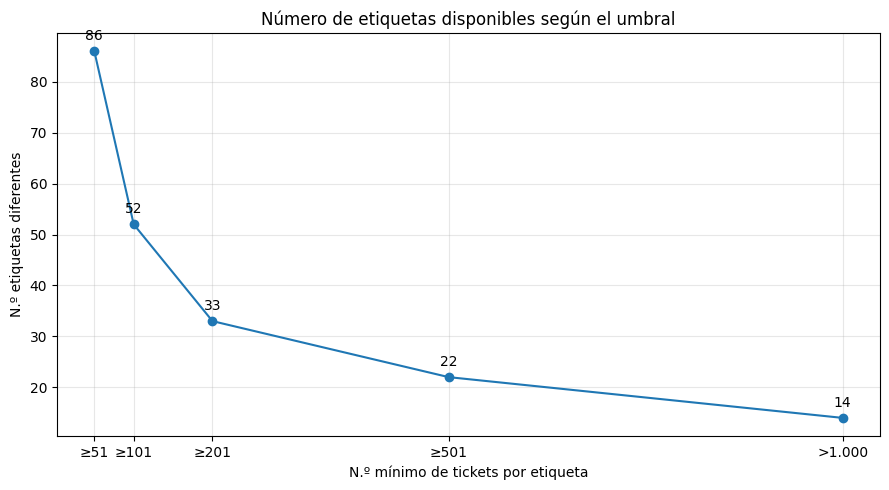

In [28]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICO: ETIQUETAS DISPONIBLES SEGÚN EL UMBRAL
# ============================================================

# Valores para el gráfico
umbrales = [51, 101, 201, 501, 1001]
n_etiquetas

# Crear gráfico
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    umbrales,
    n_etiquetas,
    marker="o"
)

# Título y ejes
ax.set_title(
    "Número de etiquetas disponibles según el umbral"
)

ax.set_xlabel(
    "N.º mínimo de tickets por etiqueta"
)

ax.set_ylabel(
    "N.º etiquetas diferentes"
)

# Etiquetas del eje X
ax.set_xticks(
    umbrales,
    ["≥51", "≥101", "≥201", "≥501", ">1.000"]
)

# Mostrar valores sobre los puntos
for x, y in zip(umbrales, n_etiquetas):
    ax.annotate(
        f"{y}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Diez etiquetas mas frecuentes**

Se han analizado las etiquetas más frecuentes para comprobar que representan categorías concretas y relevantes para la clasificación, y no términos genéricos o poco informativos

In [29]:
# Las 10 etiquetas con mayor número de tickets (en >1000)
# (Sabemos que has 22 tickets que aparecen en mas de >1000 tiquets. Mostramos 10 de ellos)
top_tags = pd.DataFrame({
    "N.º tickets": tag_frequencies.head(10)
})

display(top_tags)

,N.º tickets
Tech Support,9597
IT,9320
Performance,7536
Feedback,4814
Bug,3955
Security,3806
Feature,3741
Disruption,3428
Documentation,3425
Outage,2574


**0 vs >=1 etiqueta / ticket**

In [30]:
# Número de etiquetas por ticket
n_tags = df_eda["Tags"].apply(len)

print(f"Media de etiquetas por ticket: {n_tags.mean():.2f}")
print(f"Mediana de etiquetas por ticket: {n_tags.median():.0f}")

sin_tags = (n_tags == 0).sum()
con_tags = (n_tags >= 1).sum()

print(f"\nTickets sin etiquetas: {sin_tags:,} ({sin_tags / len(df_eda) * 100:.2f}%)")
print(f"Tickets con al menos una etiqueta: {con_tags:,} ({con_tags / len(df_eda) * 100:.2f}%)")

# Distribución del número de etiquetas por ticket
distribucion_tags = n_tags.value_counts().sort_index()

tabla_tags = pd.DataFrame({
    "N.º etiquetas por ticket": distribucion_tags.index,
    "N.º tickets": distribucion_tags.values,
    "Porcentaje (%)": (
        distribucion_tags / len(df_eda) * 100
    ).round(2)
})

display(tabla_tags)

Media de etiquetas por ticket: 4.48
Mediana de etiquetas por ticket: 4

Tickets sin etiquetas: 6 (0.04%)
Tickets con al menos una etiqueta: 16,332 (99.96%)


,N.º etiquetas por ticket,N.º tickets,Porcentaje (%)
Tags,,,
0,0,6,0.04
1,1,23,0.14
2,2,186,1.14
3,3,2101,12.86
4,4,6617,40.50
5,5,5041,30.85
6,6,1872,11.46
7,7,412,2.52
8,8,80,0.49


## 2.3. Distribución de las variables objetivo (Type, Priority, Queue)

Número de categorías y frecuencia, y analisis de desbalance de clases.

El ratio 3,92 significa que la clase mayoritaria tiene 3,92 veces más tickets que la minoritaria. Es una forma muy rápida de cuantificar el grado de desbalance.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

target_cols = ["type", "priority", "queue"]

for col in target_cols:

    # Distribución de las categorías

    frecuencias = df_eda[col].value_counts(dropna=False)
    total_validos = df_eda[col].notna().sum()

    resumen = pd.DataFrame({
        "Frecuencia": frecuencias,
        "Porcentaje (%)": (
            frecuencias / total_validos * 100
        ).round(2)
    })

    print(col.upper())

    print(
        f"Número de categorías: "
        f"{df_eda[col].nunique(dropna=True):,}"
    )

    display(resumen)

    # Desbalance de clases

    frecuencias_sin_na = df_eda[col].value_counts(
        dropna=True
    )

    clase_mayoritaria = frecuencias_sin_na.index[0]
    frecuencia_mayoritaria = frecuencias_sin_na.iloc[0]

    clase_minoritaria = frecuencias_sin_na.index[-1]
    frecuencia_minoritaria = frecuencias_sin_na.iloc[-1]

    porcentaje_mayoritaria = (
        frecuencia_mayoritaria / total_validos * 100
    )

    porcentaje_minoritaria = (
        frecuencia_minoritaria / total_validos * 100
    )

    ratio_desbalance = (
        frecuencia_mayoritaria /
        frecuencia_minoritaria
    )

    tabla_desbalance = pd.DataFrame({
        "Categoría": [
            clase_mayoritaria,
            clase_minoritaria
        ],
        "Tipo de clase": [
            "Mayoritaria",
            "Minoritaria"
        ],
        "N.º tickets": [
            frecuencia_mayoritaria,
            frecuencia_minoritaria
        ],
        "% de tickets": [
            round(porcentaje_mayoritaria, 2),
            round(porcentaje_minoritaria, 2)
        ]
    })

    print("\nDESBALANCE DE CLASES")

    display(tabla_desbalance)

    print(
        f"Ratio mayoritaria/minoritaria: "
        f"{ratio_desbalance:.2f}"
    )


TYPE
Número de categorías: 4


,Frecuencia,Porcentaje (%)
type,,
Incident,6571,40.22
Request,4665,28.55
Problem,3397,20.79
Change,1705,10.44



DESBALANCE DE CLASES


,Categoría,Tipo de clase,N.º tickets,% de tickets
0,Incident,Mayoritaria,6571,40.22
1,Change,Minoritaria,1705,10.44


Ratio mayoritaria/minoritaria: 3.85
PRIORITY
Número de categorías: 3


...

Ratio mayoritaria/minoritaria: 1.96
QUEUE
Número de categorías: 10


,Frecuencia,Porcentaje (%)
queue,,
Technical Support,4737,28.99
Product Support,3073,18.81
Customer Service,2410,14.75
IT Support,1942,11.89
Billing and Payments,1595,9.76
Returns and Exchanges,820,5.02
Service Outages and Maintenance,664,4.06
Sales and Pre-Sales,513,3.14
Human Resources,348,2.13



DESBALANCE DE CLASES


,Categoría,Tipo de clase,N.º tickets,% de tickets
0,Technical Support,Mayoritaria,4737,28.99
1,General Inquiry,Minoritaria,236,1.44


Ratio mayoritaria/minoritaria: 20.07


/tmp/ipykernel_2306/880748897.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_2306/880748897.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/tmp/ipykernel_2306/880748897.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


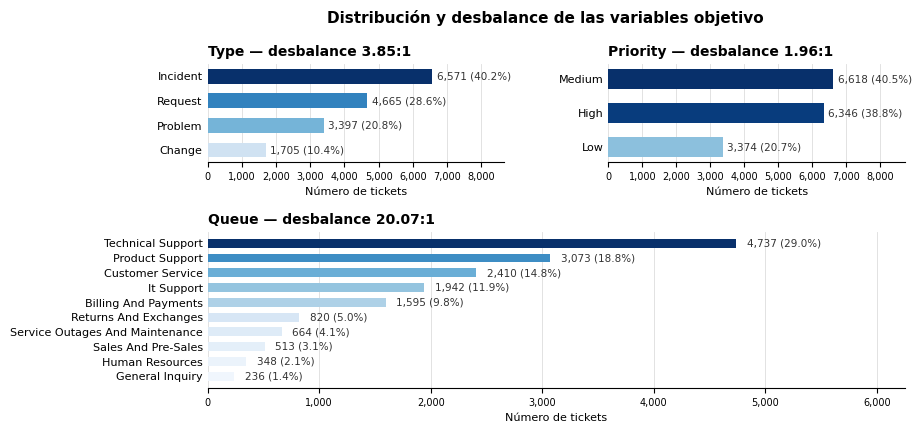

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import cm, colors as mcolors
from matplotlib.gridspec import GridSpec

def plot_distribucion_objetivo(df, col, ax, cmap_name="Blues"):
    frecuencias = df[col].value_counts(dropna=True).sort_values(ascending=True)
    total = frecuencias.sum()
    porcentajes = frecuencias / total * 100
    ratio = frecuencias.iloc[-1] / frecuencias.iloc[0]

    etiquetas = [c.replace("_", " ").title() for c in frecuencias.index]

    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=frecuencias.min() * 0.3, vmax=frecuencias.max())
    colores = [cmap(norm(v)) for v in frecuencias.values]

    barras = ax.barh(etiquetas, frecuencias.values, color=colores, height=0.6, zorder=3)

    max_val = frecuencias.max()
    for barra, valor, pct in zip(barras, frecuencias.values, porcentajes):
        ax.text(
            valor + max_val * 0.02,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:,} ({pct:.1f}%)",
            va="center", ha="left", fontsize=7.5, color="#333333"
        )

    ax.set_title(f"{col.capitalize()} — desbalance {ratio:.2f}:1", fontsize=10, fontweight="bold", pad=6, loc="left")
    ax.set_xlabel("Número de tickets", fontsize=8)
    ax.set_xlim(0, max_val * 1.32)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8, length=0)
    ax.tick_params(axis="x", labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x", color="#DDDDDD", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(9, 4.2))
gs = GridSpec(nrows=2, ncols=2, height_ratios=[1, 1.6], hspace=0.55, wspace=0.35, figure=fig)

ax_type = fig.add_subplot(gs[0, 0])
ax_priority = fig.add_subplot(gs[0, 1])
ax_queue = fig.add_subplot(gs[1, :])   # ocupa las dos columnas

plot_distribucion_objetivo(df_eda, "type", ax_type)
plot_distribucion_objetivo(df_eda, "priority", ax_priority)
plot_distribucion_objetivo(df_eda, "queue", ax_queue)

fig.suptitle("Distribución y desbalance de las variables objetivo", fontsize=11, fontweight="bold", y=1.01)
plt.savefig("distribucion_variables_objetivo.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
df_eda = df_eda.drop(
    columns=[
        "subject_words",
        "subject_chars",
        "body_words",
        "body_chars"
    ]
)

# 2.3. Preprocesamiento

### 1- NAs

In [34]:
# Comprobar valores ausentes y vacíos en Tags
n_na = df_eda["Tags"].isna().sum()
n_vacios = (df_eda["Tags"].apply(len) == 0).sum()

print(f"Valores ausentes en Tags: {n_na} ({n_na / len(df_eda) * 100:.2f} %)")
print(f"Tickets sin etiquetas: {n_vacios} ({n_vacios / len(df_eda) * 100:.2f} %)")

Valores ausentes en Tags: 0 (0.00 %)
Tickets sin etiquetas: 6 (0.04 %)


In [35]:
# Comprobar valores ausentes y vacíos en en subject
n_na = df_eda["subject"].isna().sum()

print(f"Valores ausentes en subject: {n_na} ({n_na / len(df_eda) * 100:.2f} %)")

Valores ausentes en subject: 2607 (15.96 %)


### 2- Mayusculas, espacios

In [36]:
# Tags es una variable con con una lista de valores. Limpiamos mayusculas y espacios.
df_eda["Tags"] = df_eda["Tags"].apply(
    lambda tags: [
        tag.strip().lower()
        for tag in tags
    ] if isinstance(tags, list) else []
)

# idem para el resto de variables
cols_normalizar = [
    "subject", "body", "type", "queue", "priority", "language"
]

for col in cols_normalizar:
    df_eda[col] = (
        df_eda[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

Comprobación

In [37]:
# Comprobar la limpieza de mayúsculas, espacios de las variables
for col in ["subject", "body", "type", "queue", "priority", "language"]:
    serie = df_eda[col].dropna().astype(str)

    mayusculas = serie.str.contains(r"[A-Z]", regex=True).sum()
    espacios = serie.str.contains(r"^\s|\s$", regex=True).sum()

    print(f"{col}:")
    print(f"  Valores con mayúsculas: {mayusculas}")
    print(f"  Valores con espacios al inicio/final: {espacios}")

subject:
  Valores con mayúsculas: 0
  Valores con espacios al inicio/final: 0
body:
  Valores con mayúsculas: 0
  Valores con espacios al inicio/final: 0
type:
  Valores con mayúsculas: 0
  Valores con espacios al inicio/final: 0
queue:
  Valores con mayúsculas: 0
  Valores con espacios al inicio/final: 0
priority:
  Valores con mayúsculas: 0
  Valores con espacios al inicio/final: 0
language:
  Valores con mayúsculas: 0
  Valores con espacios al inicio/final: 0


In [38]:
# Comprobar la limpieza de mayúsculas, espacios de Tags
tags_con_mayusculas = 0
tags_con_espacios = 0

for tags in df_eda["Tags"]:
    for tag in tags:
        if any(c.isupper() for c in tag):
            tags_con_mayusculas += 1
        if tag != tag.strip():
            tags_con_espacios += 1

print(f"Tags con mayúsculas: {tags_con_mayusculas}")
print(f"Tags con espacios al inicio/final: {tags_con_espacios}")

Tags con mayúsculas: 0
Tags con espacios al inicio/final: 0


### 3- Eliminar html

e.g. de un caso

In [39]:
from bs4 import BeautifulSoup

# Comprobar si queda código HTML en Body
html_restante = df_eda["body"].astype("string").str.contains(
    r"<[^>]+>", regex=True, na=False
).sum()

print(f"Tickets con HTML restante: {html_restante}")

Tickets con HTML restante: 520


In [40]:
from bs4 import BeautifulSoup

# Buscar un ticket que contenga HTML
fila = df_eda[
    df_eda["body"].notna() &
    df_eda["body"].str.contains(r"<[^>]+>", regex=True, na=False)
].iloc[0]

# Body original
body_original = fila["body"]

# Body después de eliminar HTML
body_sin_html = BeautifulSoup(
    body_original,
    "html.parser"
).get_text(" ", strip=True)

print("=== ANTES ===")
print(body_original)

print("\n=== DESPUÉS ===")
print(body_sin_html)

=== ANTES ===
dear customer support,<br><br>i am submitting a report concerning a critical problem within the billing system of the financial organization. the issue involves errors that are impacting several products related to investment data analytics and optimization. it appears that the problem is probably due to integration issues within the system. our team has attempted to review invoices and reset payment gateways, but unfortunately, we have not yet found a solution.<br><br>the errors are causing incorrect billing amounts and payments, leading to considerable disruptions in business operations. we are worried that this problem may continue to affect our activities.

=== DESPUÉS ===
dear customer support, i am submitting a report concerning a critical problem within the billing system of the financial organization. the issue involves errors that are impacting several products related to investment data analytics and optimization. it appears that the problem is probably due to i

Eliminacion de html. e.g. etiquetas \<br>

In [41]:
# Eliminar código HTML de Body
df_eda["body"] = df_eda["body"].apply(
    lambda x: BeautifulSoup(x, "html.parser").get_text(" ", strip=True)
    if pd.notna(x) else x
)

Comprobar si queda código HTML en Body

In [42]:
# Comprobar si queda código HTML en Body
html_restante = df_eda["body"].astype("string").str.contains(
    r"<[^>]+>", regex=True, na=False
).sum()

print(f"Tickets con HTML restante: {html_restante}")

Tickets con HTML restante: 0


# 3. TF-IDF. texto -> numeros


## TF-IDF Decidimos que configuraciones hacer

### 3.1. stop-words investigar

In [43]:
df_tf_idf = df_eda.copy()

Obtener la lista estándar de stopwords

In [44]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words_standard = set(stopwords.words("english"))

print("Número de stopwords estándar:", len(stop_words_standard))

Número de stopwords estándar: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Revisar las stopwords antes de eliminarlas

In [45]:
# Negaciones que queremos conservar
stop_words_keep = {
    "no",
    "not",
    "nor"
}
# Lista final de stopwords
stop_words = stop_words_standard - stop_words_keep

print("Stopwords estándar:", len(stop_words_standard))
print("Palabras conservadas:", sorted(stop_words_keep))
print("Stopwords finales:", len(stop_words))

Stopwords estándar: 198
Palabras conservadas: ['no', 'nor', 'not']
Stopwords finales: 195


In [46]:
print("Palabras conservadas de la lista estándar:")
print(sorted(stop_words_standard.intersection(stop_words_keep)))

print("\n¿Siguen siendo stopwords?")
for word in sorted(stop_words_keep):
    print(f"{word}: {word in stop_words}")

Palabras conservadas de la lista estándar:
['no', 'nor', 'not']

¿Siguen siendo stopwords?
no: False
nor: False
not: False


Miramos si esta lista de step-words está en nuestros textos

In [47]:
from collections import Counter
import re

# Contar frecuencia de las stopwords finales en Subject + Body
text_all = (
    df_tf_idf["subject"].fillna("") + " " +
    df_tf_idf["body"].fillna("")
)

words_all = re.findall(r"\b\w+\b", " ".join(text_all))

word_freq = Counter(words_all)

stopword_freq = {
    word: word_freq[word]
    for word in stop_words
    if word_freq[word] > 0
}

stopword_freq_df = (
    pd.DataFrame(
        sorted(stopword_freq.items(), key=lambda x: x[1], reverse=True),
        columns=["stopword", "frecuencia"]
    )
)

print("Stopwords presentes en el corpus:", len(stopword_freq_df))
print()
print(stopword_freq_df.to_string(index=False))

Stopwords presentes en el corpus: 118

 stopword  frecuencia
      the       42439
       to       37271
      and       30488
       in       12175
      for       12074
        i       11535
      you       11258
        a       10680
       on       10043
       we        9414
     with        9369
     this        9180
      our        7765
     your        7716
       of        7538
       is        7408
     have        7239
       be        7022
      are        5652
       am        4963
     that        4952
       as        4753
    about        4301
       or        3962
      any        3920
       it        3783
      has        3620
     been        3297
      but        3241
       an        2827
    these        2823
       if        2814
    which        2605
        s        2477
       by        2429
      can        2321
      how        2211
     from        1939
    there        1635
      out        1455
     into        1412
       me        1389
       my      

### stop-words eliminamos

In [48]:
def remove_stopwords(text):
    words = re.findall(r"\b\w+\b", text)
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df_tf_idf["subject"] = (
    df_tf_idf["subject"]
    .fillna("")
    .apply(remove_stopwords)
)

df_tf_idf["body"] = (
    df_tf_idf["body"]
    .fillna("")
    .apply(remove_stopwords)
)

In [49]:
from collections import Counter
import re

# Contar frecuencia de las stopwords finales en Subject + Body
text_all = (
    df_tf_idf["subject"].fillna("") + " " +
    df_tf_idf["body"].fillna("")
)

words_all = re.findall(r"\b\w+\b", " ".join(text_all))

word_freq = Counter(words_all)

stopword_freq = {
    word: word_freq[word]
    for word in stop_words
    if word_freq[word] > 0
}

stopword_freq_df = (
    pd.DataFrame(
        sorted(stopword_freq.items(), key=lambda x: x[1], reverse=True),
        columns=["stopword", "frecuencia"]
    )
)

print("Stopwords presentes en el corpus:", len(stopword_freq_df))
print()
print(stopword_freq_df.to_string(index=False))

Stopwords presentes en el corpus: 0

Empty DataFrame
Columns: [stopword, frecuencia]
Index: []


### 3.2. texto sin lematizar vs Lematización (~ Ejecucion tarda 4 mins)

In [50]:
df_tf_idf_lem = df_tf_idf.copy()

Descargar y preparar el lematizador

In [51]:
import spacy
import subprocess
import sys

# Instalar el modelo si no está disponible
subprocess.run(
    [sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
    check=True
)

nlp = spacy.load("en_core_web_sm")

Aplicar lematización a Subject y Body

In [52]:
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_space
    )

df_tf_idf_lem["subject"] = (
    df_tf_idf_lem["subject"]
    .fillna("")
    .apply(lemmatize_text)
)

df_tf_idf_lem["body"] = (
    df_tf_idf_lem["body"]
    .fillna("")
    .apply(lemmatize_text)
)

### vs (vocabulario unico)

Reducción del vocabulario. *Nota: no podemos concluir que sea mejor con lematizacion, eso lo dirá el modelo.*

In [53]:
from collections import Counter
import re

def get_vocabulary(df):
    text = (
        df["subject"].fillna("") + " " +
        df["body"].fillna("")
    )

    words = re.findall(r"\b\w+\b", " ".join(text))
    return set(words)

vocab_sin_lem = get_vocabulary(df_tf_idf)
vocab_con_lem = get_vocabulary(df_tf_idf_lem)

n_sin_lem = len(vocab_sin_lem)
n_con_lem = len(vocab_con_lem)

reduccion = (n_sin_lem - n_con_lem) / n_sin_lem * 100

print("Vocabulario sin lematización:", n_sin_lem)
print("Vocabulario con lematización:", n_con_lem)
print(f"Reducción del vocabulario: {reduccion:.2f}%")

Vocabulario sin lematización: 5033
Vocabulario con lematización: 3848
Reducción del vocabulario: 23.54%


e.g.

In [54]:
# Términos presentes sin lematizar pero no como tales después de lematizar
terminos_reducidos = sorted(vocab_sin_lem - vocab_con_lem)

ejemplos = []

for termino in terminos_reducidos:
    doc = nlp(termino)
    lema = " ".join(token.lemma_ for token in doc)

    # Solo mostramos casos donde el lema sea diferente
    if lema != termino and lema in vocab_con_lem:
        ejemplos.append((termino, lema))

# Mostrar los primeros 30 ejemplos
ejemplos[:30]

[('abilities', 'ability'),
 ('accelerating', 'accelerate'),
 ('accepted', 'accept'),
 ('accessed', 'access'),
 ('accessories', 'accessory'),
 ('accommodates', 'accommodate'),
 ('accompanied', 'accompany'),
 ('accomplished', 'accomplish'),
 ('according', 'accord'),
 ('accounts', 'account'),
 ('achievements', 'achievement'),
 ('achieving', 'achieve'),
 ('acknowledges', 'acknowledge'),
 ('acknowledging', 'acknowledge'),
 ('acquired', 'acquire'),
 ('acquisitions', 'acquisition'),
 ('acting', 'act'),
 ('actions', 'action'),
 ('activated', 'activate'),
 ('activating', 'activate'),
 ('activities', 'activity'),
 ('actors', 'actor'),
 ('adapted', 'adapt'),
 ('adapters', 'adapter'),
 ('adapting', 'adapt'),
 ('adapts', 'adapt'),
 ('added', 'add'),
 ('adding', 'add'),
 ('additions', 'addition'),
 ('addressed', 'address')]

In [55]:
from collections import defaultdict, Counter

# Frecuencia de cada término antes de lematizar
text = (
    df_tf_idf["subject"].fillna("") + " " +
    df_tf_idf["body"].fillna("")
)

words = re.findall(r"\b\w+\b", " ".join(text))
freq_original = Counter(words)

# Agrupar formas originales por lema
grupos = defaultdict(list)

for termino in vocab_sin_lem:
    doc = nlp(termino)
    lema = " ".join(token.lemma_ for token in doc)

    if lema != termino and lema in vocab_con_lem:
        grupos[lema].append(termino)

# Calcular frecuencia total de cada grupo
resultado = []

for lema, formas in grupos.items():
    frecuencia_total = sum(freq_original[forma] for forma in formas)
    resultado.append(
        (lema, len(formas), frecuencia_total, sorted(formas))
    )

# Ordenar por frecuencia total descendente
resultado = sorted(
    resultado,
    key=lambda x: x[2],
    reverse=True
)

for lema, n_formas, frecuencia, formas in resultado[:20]:
    print(f"{lema}: {frecuencia} apariciones | {n_formas} formas")
    print(f"  {formas}")
    print()

datum: 13928 apariciones | 1 formas
  ['data']

analytic: 5064 apariciones | 1 formas
  ['analytics']

update: 4715 apariciones | 3 formas
  ['updated', 'updates', 'updating']

detail: 3800 apariciones | 3 formas
  ['detailed', 'detailing', 'details']

tool: 3723 apariciones | 1 formas
  ['tools']

issue: 3713 apariciones | 3 formas
  ['issued', 'issues', 'issuing']

strategy: 3223 apariciones | 1 formas
  ['strategies']

system: 2753 apariciones | 1 formas
  ['systems']

attempt: 2707 apariciones | 3 formas
  ['attempted', 'attempting', 'attempts']

restart: 2477 apariciones | 3 formas
  ['restarted', 'restarting', 'restarts']

we: 2474 apariciones | 1 formas
  ['us']

service: 2180 apariciones | 1 formas
  ['services']

problem: 2172 apariciones | 1 formas
  ['problems']

resolve: 2150 apariciones | 3 formas
  ['resolved', 'resolves', 'resolving']

encounter: 2095 apariciones | 3 formas
  ['encountered', 'encountering', 'encounters']

step: 2027 apariciones | 1 formas
  ['steps']

af

### 3.3. TF-IDF caracteres? (-;no)

In [56]:
import re
from collections import Counter
from difflib import SequenceMatcher

# 1. Extraer palabras
text = (
    df_eda["subject"].fillna("") + " " +
    df_eda["body"].fillna("")
).str.lower()

tokens = re.findall(r"\b[a-z]{3,}\b", " ".join(text))

freq = Counter(tokens)

# 2. Palabras raras y frecuentes
rare_words = [w for w, f in freq.items() if f <= 5]
common_words = [w for w, f in freq.items() if f >= 50]

# 3. Sufijos que suelen representar variaciones morfológicas
suffixes = (
    "s", "es", "ed", "ing", "ly",
    "er", "ers", "est", "tion", "tions"
)

def likely_morphological(a, b):
    """Descarta diferencias que parecen simples variaciones morfológicas."""
    for suffix in suffixes:
        if a + suffix == b or b + suffix == a:
            return True
    return False

# 4. Buscar candidatos: palabra rara + palabra frecuente muy similar
candidates = []

for rare in rare_words:
    # Evitar artefactos del tipo ncustomer -> customer
    if len(rare) > 3 and rare[1:] in freq and freq[rare[1:]] >= 50:
        continue

    for common in common_words:
        if abs(len(rare) - len(common)) > 2:
            continue

        if likely_morphological(rare, common):
            continue

        similarity = SequenceMatcher(None, rare, common).ratio()

        if similarity >= 0.92:
            candidates.append(
                (rare, freq[rare], common, freq[common], round(similarity, 2))
            )

# 5. Ordenar por similitud y frecuencia de la palabra correcta
candidates = sorted(
    candidates,
    key=lambda x: (-x[4], -x[3])
)

print("Palabras totales:", len(tokens))
print("Palabras únicas:", len(freq))
print("\nPosibles faltas ortográficas:\n")

for row in candidates[:50]:
    print(
        f"{row[0]} ({row[1]}) → "
        f"{row[2]} ({row[3]}) "
        f"similaridad={row[4]}"
    )

Palabras totales: 812829
Palabras únicas: 4971

Posibles faltas ortográficas:

incorporated (3) → incorporate (72) similaridad=0.96
facilitated (5) → facilitate (253) similaridad=0.95
attribute (2) → attributed (79) similaridad=0.95
introduce (4) → introduced (69) similaridad=0.95
structured (3) → structure (57) similaridad=0.95
reconciled (2) → reconcile (51) similaridad=0.95
resynchronization (1) → synchronization (537) similaridad=0.94
minimized (1) → minimize (245) similaridad=0.94
mitigated (2) → mitigate (79) similaridad=0.94
estimate (3) → estimated (51) similaridad=0.94
probleme (1) → problem (5047) similaridad=0.93
inquired (3) → inquire (813) similaridad=0.93
reconfiguration (1) → configuration (593) similaridad=0.93
reconfigurations (2) → configurations (514) similaridad=0.93
explored (5) → explore (193) similaridad=0.93
ineffectiveness (5) → effectiveness (175) similaridad=0.93
settling (2) → setting (166) similaridad=0.93
invoiced (1) → invoice (161) similaridad=0.93
promo

### TF-IDF distribución de frecuencias del vocabulario

In [57]:
from collections import Counter
import re
import pandas as pd

def get_term_frequencies(df):
    text = (
        df["subject"].fillna("") + " " +
        df["body"].fillna("")
    )

    words = re.findall(r"\b\w+\b", " ".join(text))
    return Counter(words)


term_freq = {
    "sin_lem": get_term_frequencies(df_tf_idf),
    "con_lem": get_term_frequencies(df_tf_idf_lem)
}

thresholds = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200]

results = []

for version, freq in term_freq.items():
    total_vocab = len(freq)

    for threshold in thresholds:
        vocab = sum(f >= threshold for f in freq.values())

        results.append({
            "version": version,
            "min_df": threshold,
            "terminos_vocabulario": vocab,
            "terminos_eliminados": total_vocab - vocab,
            "porcentaje_conservado": round(vocab / total_vocab * 100, 2)
        })

results = pd.DataFrame(results)

print(results.to_string(index=False))

version  min_df  terminos_vocabulario  terminos_eliminados  porcentaje_conservado
sin_lem       1                  5033                    0                 100.00
sin_lem       2                  4243                  790                  84.30
sin_lem       3                  3805                 1228                  75.60
sin_lem       5                  3206                 1827                  63.70
sin_lem      10                  2523                 2510                  50.13
sin_lem      20                  1902                 3131                  37.79
sin_lem      30                  1593                 3440                  31.65
sin_lem      50                  1242                 3791                  24.68
sin_lem     100                   821                 4212                  16.31
sin_lem     200                   528                 4505                  10.49
con_lem       1                  3848                    0                 100.00
con_lem       2 

20 y 100.

## TF-IDF Creamos las 8 configuraciones Subject + Body

*   df_tf_idf
*   df_tf_idf_lem

Los resultados se guardarán como matrices dispersas, que son más adecuadas para TF-IDF que convertirlas en DataFrames densos.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

1. Preparar el texto (Unimos subject y body dentro de cada ticket.)

In [59]:
text_sin_lem = (
    df_tf_idf["subject"].fillna("") + " " +
    df_tf_idf["body"].fillna("")
)

text_con_lem = (
    df_tf_idf_lem["subject"].fillna("") + " " +
    df_tf_idf_lem["body"].fillna("")
)

2. Crear las ocho configuraciones

In [60]:
tfidf_vectorizers = {}
X_tfidf = {}

Sin lematización

In [61]:
# 1. Sin lematización + unigramas + frecuencia baja
tfidf_vectorizers["sin_lem_baja"] = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=20
)

X_tfidf["sin_lem_baja"] = (
    tfidf_vectorizers["sin_lem_baja"]
    .fit_transform(text_sin_lem)
)


# 2. Sin lematización + unigramas + frecuencia media
tfidf_vectorizers["sin_lem_media"] = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=100
)

X_tfidf["sin_lem_media"] = (
    tfidf_vectorizers["sin_lem_media"]
    .fit_transform(text_sin_lem)
)


# 3. Sin lematización + unigramas y bigramas + frecuencia baja
tfidf_vectorizers["sin_lem_baja_bigr"] = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=20
)

X_tfidf["sin_lem_baja_bigr"] = (
    tfidf_vectorizers["sin_lem_baja_bigr"]
    .fit_transform(text_sin_lem)
)


# 4. Sin lematización + unigramas y bigramas + frecuencia media
tfidf_vectorizers["sin_lem_media_bigr"] = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=100
)

X_tfidf["sin_lem_media_bigr"] = (
    tfidf_vectorizers["sin_lem_media_bigr"]
    .fit_transform(text_sin_lem)
)

Con lematización

In [62]:
# 5. Con lematización + unigramas + frecuencia baja
tfidf_vectorizers["con_lem_baja"] = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=20
)

X_tfidf["con_lem_baja"] = (
    tfidf_vectorizers["con_lem_baja"]
    .fit_transform(text_con_lem)
)


# 6. Con lematización + unigramas + frecuencia media
tfidf_vectorizers["con_lem_media"] = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=100
)

X_tfidf["con_lem_media"] = (
    tfidf_vectorizers["con_lem_media"]
    .fit_transform(text_con_lem)
)


# 7. Con lematización + unigramas y bigramas + frecuencia baja
tfidf_vectorizers["con_lem_baja_bigr"] = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=20
)

X_tfidf["con_lem_baja_bigr"] = (
    tfidf_vectorizers["con_lem_baja_bigr"]
    .fit_transform(text_con_lem)
)


# 8. Con lematización + unigramas y bigramas + frecuencia media
tfidf_vectorizers["con_lem_media_bigr"] = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=100
)

X_tfidf["con_lem_media_bigr"] = (
    tfidf_vectorizers["con_lem_media_bigr"]
    .fit_transform(text_con_lem)
)

3. Comprobar las dimensiones

In [63]:
for nombre, matriz in X_tfidf.items():
    print(f"{nombre}: {matriz.shape}")

sin_lem_baja: (16338, 1817)
sin_lem_media: (16338, 769)
sin_lem_baja_bigr: (16338, 6005)
sin_lem_media_bigr: (16338, 1380)
con_lem_baja: (16338, 1448)
con_lem_media: (16338, 664)
con_lem_baja_bigr: (16338, 5889)
con_lem_media_bigr: (16338, 1353)


# 4.1 TF-IDF. Modelos Subject + Body



## Preparacion variables objetivo



In [64]:
y_type = df_tf_idf["type"]
y_priority = df_tf_idf["priority"]
y_queue = df_tf_idf["queue"]

El desbalance, visto en el EDA, será especialmente relevante al seleccionar las métricas de evaluación y los parámetros de los modelos.

* Type: 4 clases. Hay un desequilibrio moderado: incident representa el 40,22 % y change el 10,44 %.
* Priority: 3 clases. Está relativamente equilibrada: medium 40,51 %, high 38,84 % y low 20,65 %.
* Queue: 10 clases. Presenta un desequilibrio importante: technical support representa el 28,99 %, mientras que general inquiry solo el 1,44 %.



## Algoritmos

Algoritmos con sus dos configuraciones de hiperparámetros:

* Regresión logística.
* Linear SVM (LinearSVC).
* SGDClassifier.


## División entre entrenamiento, validación y test

70 % entrenamiento.
15 % validación.
15 % test.

1. Primera división: entrenamiento y conjunto temporal de evaluación

In [65]:
from sklearn.model_selection import train_test_split

indices = df_tf_idf.index

idx_train, idx_temp = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=y_type
)

2. Segunda división: validación y test

Dividimos el 30 % restante en dos partes iguales:
* 15 % del total para validación.
* 15 % del total para test.

estratificar según la variable objetivo que se esté prediciendo:
* Para los modelos que predicen Type, se estratifica por Type.
* Para los modelos que predicen Priority, se estratifica por Priority.
* Para los modelos que predicen Queue, se estratifica por Queue.


In [66]:
from sklearn.model_selection import train_test_split

def crear_particion(y):
    indices = y.index

    idx_train, idx_temp = train_test_split(
        indices,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    idx_val, idx_test = train_test_split(
        idx_temp,
        test_size=0.50,
        random_state=42,
        stratify=y.loc[idx_temp]
    )

    return idx_train, idx_val, idx_test


idx_train_type, idx_val_type, idx_test_type = crear_particion(y_type)

idx_train_priority, idx_val_priority, idx_test_priority = crear_particion(y_priority)

idx_train_queue, idx_val_queue, idx_test_queue = crear_particion(y_queue)

comprobamos que las tres particiones mantienen la distribución de su propia variable objetivo y que no hay clases ausentes en validación o test.

In [67]:
def distribucion_clases(y, indices, nombre_columna="Clase"):
    conteo = y.loc[indices].value_counts().sort_index()
    porcentaje = (
        y.loc[indices]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )

    return pd.DataFrame({
        nombre_columna: conteo.index,
        "n": conteo.values,
        "porcentaje": porcentaje.values
    }).set_index(nombre_columna)

In [68]:
def comprobar_particion(y, idx_train, idx_val, idx_test, nombre):
    tabla = pd.concat(
        [
            distribucion_clases(y, y.index, "Clase").rename(
                columns={"n": "total_n", "porcentaje": "total_%"}
            ),
            distribucion_clases(y, idx_train, "Clase").rename(
                columns={"n": "train_n", "porcentaje": "train_%"}
            ),
            distribucion_clases(y, idx_val, "Clase").rename(
                columns={"n": "val_n", "porcentaje": "val_%"}
            ),
            distribucion_clases(y, idx_test, "Clase").rename(
                columns={"n": "test_n", "porcentaje": "test_%"}
            ),
        ],
        axis=1
    )

    print(nombre)
    print(tabla.round(2))

    print("\nTamaños:")
    print("Entrenamiento:", len(idx_train))
    print("Validación:", len(idx_val))
    print("Test:", len(idx_test))
    print("Suma:", len(idx_train) + len(idx_val) + len(idx_test))

    print("\nClases ausentes:")
    print("Train:", set(y.unique()) - set(y.loc[idx_train].unique()))
    print("Val:", set(y.unique()) - set(y.loc[idx_val].unique()))
    print("Test:", set(y.unique()) - set(y.loc[idx_test].unique()))


comprobar_particion(
    y_type,
    idx_train_type,
    idx_val_type,
    idx_test_type,
    "Type"
)

comprobar_particion(
    y_priority,
    idx_train_priority,
    idx_val_priority,
    idx_test_priority,
    "Priority"
)

comprobar_particion(
    y_queue,
    idx_train_queue,
    idx_val_queue,
    idx_test_queue,
    "Queue"
)

Type
          total_n  total_%  train_n  train_%  val_n  val_%  test_n  test_%
Clase                                                                     
change       1705    10.44     1193    10.43    256  10.44     256   10.44
incident     6571    40.22     4600    40.22    986  40.23     985   40.19
problem      3397    20.79     2378    20.79    509  20.77     510   20.81
request      4665    28.55     3265    28.55    700  28.56     700   28.56

Tamaños:
Entrenamiento: 11436
Validación: 2451
Test: 2451
Suma: 16338

Clases ausentes:
Train: set()
Val: set()
Test: set()
Priority
        total_n  total_%  train_n  train_%  val_n  val_%  test_n  test_%
Clase                                                                   
high       6346    38.84     4442    38.84    952  38.84     952   38.84
low        3374    20.65     2362    20.65    506  20.64     506   20.64
medium     6618    40.51     4632     40.5    993  40.51     993   40.51

Tamaños:
Entrenamiento: 11436
Validación: 245

## Entrenamiento Regresión Logística

Entrenamos primero un algoritmo completo para las tres variables objetivo.

### 1. Entrenamos las 16 combinaciones de Regresión logística para cada variable objetivo. (aprox 5 min)

In [69]:
pos_train_type = df_tf_idf.index.get_indexer(idx_train_type)
pos_train_priority = df_tf_idf.index.get_indexer(idx_train_priority)
pos_train_queue = df_tf_idf.index.get_indexer(idx_train_queue)

In [70]:
from sklearn.linear_model import LogisticRegression

configuraciones_lr = {
    "lr_c1": {
        "C": 1,
        "class_weight": "balanced",
        "max_iter": 1000,
        "random_state": 42
    },
    "lr_c10": {
        "C": 10,
        "class_weight": "balanced",
        "max_iter": 1000,
        "random_state": 42
    }
}

objetivos = {
    "type": {
        "y": y_type,
        "idx_train": pos_train_type
    },
    "priority": {
        "y": y_priority,
        "idx_train": pos_train_priority
    },
    "queue": {
        "y": y_queue,
        "idx_train": pos_train_queue
    }
}

modelos_lr = {}

for nombre_objetivo, datos in objetivos.items():
    y = datos["y"]
    idx_train = datos["idx_train"]

    modelos_lr[nombre_objetivo] = {}

    for nombre_config, parametros in configuraciones_lr.items():

        modelos_lr[nombre_objetivo][nombre_config] = {}

        for nombre_tfidf, X in X_tfidf.items():

            modelo = LogisticRegression(**parametros)

            modelo.fit(
                X[idx_train],
                y.iloc[idx_train]
            )

            modelos_lr[nombre_objetivo][nombre_config][nombre_tfidf] = modelo

            print(
                f"Entrenado: objetivo={nombre_objetivo}, "
                f"configuración={nombre_config}, "
                f"tfidf={nombre_tfidf}"
            )

Entrenado: objetivo=type, configuración=lr_c1, tfidf=sin_lem_baja
Entrenado: objetivo=type, configuración=lr_c1, tfidf=sin_lem_media
Entrenado: objetivo=type, configuración=lr_c1, tfidf=sin_lem_baja_bigr
Entrenado: objetivo=type, configuración=lr_c1, tfidf=sin_lem_media_bigr
Entrenado: objetivo=type, configuración=lr_c1, tfidf=con_lem_baja
Entrenado: objetivo=type, configuración=lr_c1, tfidf=con_lem_media
Entrenado: objetivo=type, configuración=lr_c1, tfidf=con_lem_baja_bigr
Entrenado: objetivo=type, configuración=lr_c1, tfidf=con_lem_media_bigr
Entrenado: objetivo=type, configuración=lr_c10, tfidf=sin_lem_baja
Entrenado: objetivo=type, configuración=lr_c10, tfidf=sin_lem_media
Entrenado: objetivo=type, configuración=lr_c10, tfidf=sin_lem_baja_bigr
Entrenado: objetivo=type, configuración=lr_c10, tfidf=sin_lem_media_bigr
Entrenado: objetivo=type, configuración=lr_c10, tfidf=con_lem_baja
Entrenado: objetivo=type, configuración=lr_c10, tfidf=con_lem_media
Entrenado: objetivo=type, configu

### 2.Después evaluamos esas 16 combinaciones sobre validación.

In [71]:
# Convertir los índices originales del DataFrame a posiciones de las matrices TF-IDF

pos_train_type = df_tf_idf.index.get_indexer(idx_train_type)
pos_val_type = df_tf_idf.index.get_indexer(idx_val_type)
pos_test_type = df_tf_idf.index.get_indexer(idx_test_type)

pos_train_priority = df_tf_idf.index.get_indexer(idx_train_priority)
pos_val_priority = df_tf_idf.index.get_indexer(idx_val_priority)
pos_test_priority = df_tf_idf.index.get_indexer(idx_test_priority)

pos_train_queue = df_tf_idf.index.get_indexer(idx_train_queue)
pos_val_queue = df_tf_idf.index.get_indexer(idx_val_queue)
pos_test_queue = df_tf_idf.index.get_indexer(idx_test_queue)

In [72]:
print(len(pos_val_type), len(pos_val_priority), len(pos_val_queue))

2451 2451 2451


In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

particiones_val = {
    "type": {
        "y": y_type,
        "idx_val": pos_val_type
    },
    "priority": {
        "y": y_priority,
        "idx_val": pos_val_priority
    },
    "queue": {
        "y": y_queue,
        "idx_val": pos_val_queue
    }
}

resultados_lr = []

for nombre_objetivo, datos in particiones_val.items():

    y = datos["y"]
    idx_val = datos["idx_val"]

    for nombre_config, modelos_tfidf in modelos_lr[nombre_objetivo].items():

        for nombre_tfidf, modelo in modelos_tfidf.items():

            X = X_tfidf[nombre_tfidf]

            y_val = y.iloc[idx_val]
            pred_val = modelo.predict(X[idx_val])

            resultados_lr.append({
                "objetivo": nombre_objetivo,
                "configuracion": nombre_config,
                "tfidf": nombre_tfidf,
                "accuracy": accuracy_score(y_val, pred_val),
                "precision_macro": precision_score(
                    y_val,
                    pred_val,
                    average="macro",
                    zero_division=0
                ),
                "recall_macro": recall_score(
                    y_val,
                    pred_val,
                    average="macro",
                    zero_division=0
                ),
                "f1_macro": f1_score(
                    y_val,
                    pred_val,
                    average="macro",
                    zero_division=0
                )
            })

resultados_lr = pd.DataFrame(resultados_lr)

print("Dimensiones:", resultados_lr.shape)
resultados_lr.head()

Dimensiones: (48, 7)


,objetivo,configuracion,tfidf,accuracy,precision_macro,recall_macro,f1_macro
0,type,lr_c1,sin_lem_baja,0.817217,0.834921,0.847452,0.837523
1,type,lr_c1,sin_lem_media,0.795186,0.816306,0.830133,0.818840
2,type,lr_c1,sin_lem_baja_bigr,0.831089,0.846342,0.857364,0.849226
3,type,lr_c1,sin_lem_media_bigr,0.802938,0.821091,0.835322,0.824564
4,type,lr_c1,con_lem_baja,0.808650,0.826514,0.839162,0.829178


In [74]:
mejores_lr = (
    resultados_lr
    .sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    )
    .groupby("objetivo")
    .head(5)
)

mejores_lr

,objetivo,configuracion,tfidf,accuracy,precision_macro,recall_macro,f1_macro
26,priority,lr_c10,sin_lem_baja_bigr,0.601795,0.587678,0.592007,0.589465
30,priority,lr_c10,con_lem_baja_bigr,0.591595,0.579628,0.585732,0.582138
18,priority,lr_c1,sin_lem_baja_bigr,0.573643,0.562716,0.575225,0.565354
22,priority,lr_c1,con_lem_baja_bigr,0.558548,0.547219,0.559559,0.549934
24,priority,lr_c10,sin_lem_baja,0.522236,0.513160,0.525098,0.515092
42,queue,lr_c10,sin_lem_baja_bigr,0.563851,0.578758,0.606837,0.591200
46,queue,lr_c10,con_lem_baja_bigr,0.563851,0.569072,0.597004,0.580733
34,queue,lr_c1,sin_lem_baja_bigr,0.468788,0.436419,0.545337,0.469801
40,queue,lr_c10,sin_lem_baja,0.460628,0.439743,0.536428,0.469468
38,queue,lr_c1,con_lem_baja_bigr,0.470012,0.436680,0.545135,0.467165


In [75]:
mejor_por_objetivo_lr = (
    resultados_lr
    .sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    )
    .groupby("objetivo")
    .head(1)
    .reset_index(drop=True)
)

mejor_por_objetivo_lr

,objetivo,configuracion,tfidf,accuracy,precision_macro,recall_macro,f1_macro
0,priority,lr_c10,sin_lem_baja_bigr,0.601795,0.587678,0.592007,0.589465
1,queue,lr_c10,sin_lem_baja_bigr,0.563851,0.578758,0.606837,0.591200
2,type,lr_c10,con_lem_baja_bigr,0.848633,0.859108,0.865653,0.861748


## Entrenamiento LinearSVC

### 1. Entrenamos las 16 combinaciones de LineasSVC para cada variable objetivo. (aprox 5 min)

In [76]:
from sklearn.svm import LinearSVC

configuraciones_svm = {
    "svm_c1": {
        "C": 1,
        "class_weight": "balanced",
        "max_iter": 5000,
        "random_state": 42
    },
    "svm_c10": {
        "C": 10,
        "class_weight": "balanced",
        "max_iter": 5000,
        "random_state": 42
    }
}

modelos_svm = {}

for nombre_objetivo, datos in objetivos.items():
    y = datos["y"]
    idx_train = datos["idx_train"]

    modelos_svm[nombre_objetivo] = {}

    for nombre_config, parametros in configuraciones_svm.items():
        modelos_svm[nombre_objetivo][nombre_config] = {}

        for nombre_tfidf, X in X_tfidf.items():
            modelo = LinearSVC(**parametros)

            modelo.fit(
                X[idx_train],
                y.iloc[idx_train]
            )

            modelos_svm[nombre_objetivo][nombre_config][nombre_tfidf] = modelo

            print(
                f"Objetivo: {nombre_objetivo} | "
                f"Configuración: {nombre_config} | "
                f"TF-IDF: {nombre_tfidf}"
            )

Objetivo: type | Configuración: svm_c1 | TF-IDF: sin_lem_baja
Objetivo: type | Configuración: svm_c1 | TF-IDF: sin_lem_media
Objetivo: type | Configuración: svm_c1 | TF-IDF: sin_lem_baja_bigr
Objetivo: type | Configuración: svm_c1 | TF-IDF: sin_lem_media_bigr
Objetivo: type | Configuración: svm_c1 | TF-IDF: con_lem_baja
Objetivo: type | Configuración: svm_c1 | TF-IDF: con_lem_media
Objetivo: type | Configuración: svm_c1 | TF-IDF: con_lem_baja_bigr
Objetivo: type | Configuración: svm_c1 | TF-IDF: con_lem_media_bigr
Objetivo: type | Configuración: svm_c10 | TF-IDF: sin_lem_baja
Objetivo: type | Configuración: svm_c10 | TF-IDF: sin_lem_media
Objetivo: type | Configuración: svm_c10 | TF-IDF: sin_lem_baja_bigr
Objetivo: type | Configuración: svm_c10 | TF-IDF: sin_lem_media_bigr
Objetivo: type | Configuración: svm_c10 | TF-IDF: con_lem_baja
Objetivo: type | Configuración: svm_c10 | TF-IDF: con_lem_media
Objetivo: type | Configuración: svm_c10 | TF-IDF: con_lem_baja_bigr
Objetivo: type | Conf

### 2.Después evaluamos esas 16 combinaciones sobre validación.

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

particiones_val = {
    "type": {"y": y_type, "idx_val": pos_val_type},
    "priority": {"y": y_priority, "idx_val": pos_val_priority},
    "queue": {"y": y_queue, "idx_val": pos_val_queue}
}

resultados_svm = []

for nombre_objetivo, datos in particiones_val.items():
    y = datos["y"]
    idx_val = datos["idx_val"]

    for nombre_config, modelos_tfidf in modelos_svm[nombre_objetivo].items():
        for nombre_tfidf, modelo in modelos_tfidf.items():

            X = X_tfidf[nombre_tfidf]
            y_val = y.iloc[idx_val]

            pred_val = modelo.predict(X[idx_val])

            resultados_svm.append({
                "objetivo": nombre_objetivo,
                "configuracion": nombre_config,
                "tfidf": nombre_tfidf,
                "accuracy": accuracy_score(y_val, pred_val),
                "precision_macro": precision_score(
                    y_val, pred_val,
                    average="macro",
                    zero_division=0
                ),
                "recall_macro": recall_score(
                    y_val, pred_val,
                    average="macro",
                    zero_division=0
                ),
                "f1_macro": f1_score(
                    y_val, pred_val,
                    average="macro",
                    zero_division=0
                )
            })

resultados_svm = pd.DataFrame(resultados_svm)

print("Dimensiones:", resultados_svm.shape)
print(resultados_svm.head())

Dimensiones: (48, 7)
  objetivo configuracion               tfidf  accuracy  precision_macro  \
0     type        svm_c1        sin_lem_baja  0.831905         0.842526   
1     type        svm_c1       sin_lem_media  0.813953         0.825314   
2     type        svm_c1   sin_lem_baja_bigr  0.853121         0.863852   
3     type        svm_c1  sin_lem_media_bigr  0.820889         0.831948   
4     type        svm_c1        con_lem_baja  0.826601         0.835465   

   recall_macro  f1_macro  
0      0.842871  0.842671  
1      0.826414  0.825849  
2      0.861842  0.862825  
3      0.833308  0.832623  
4      0.837942  0.836678  


In [78]:
mejores_svm = (
    resultados_svm
    .sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    )
    .groupby("objetivo")
    .head(5)
)

mejores_svm

,objetivo,configuracion,tfidf,accuracy,precision_macro,recall_macro,f1_macro
18,priority,svm_c1,sin_lem_baja_bigr,0.607915,0.594355,0.593648,0.593976
22,priority,svm_c1,con_lem_baja_bigr,0.597715,0.585217,0.586080,0.585631
26,priority,svm_c10,sin_lem_baja_bigr,0.598531,0.584912,0.580584,0.582482
30,priority,svm_c10,con_lem_baja_bigr,0.587107,0.575668,0.574715,0.575019
16,priority,svm_c1,sin_lem_baja,0.529988,0.515586,0.519696,0.516947
42,queue,svm_c10,sin_lem_baja_bigr,0.583435,0.603955,0.614239,0.608326
46,queue,svm_c10,con_lem_baja_bigr,0.575275,0.598925,0.583000,0.588958
34,queue,svm_c1,sin_lem_baja_bigr,0.563443,0.553005,0.622044,0.582027
38,queue,svm_c1,con_lem_baja_bigr,0.568747,0.553276,0.617235,0.580289
40,queue,svm_c10,sin_lem_baja,0.463892,0.437889,0.521953,0.466806


## Entrenamiento SGDClassifier

### 1. Entrenamos las 16 combinaciones de SGDClassifier para cada variable objetivo. (aprox 5 min)

In [79]:
from sklearn.linear_model import SGDClassifier

configuraciones_sgd = {
    "sgd_a0001": {
        "loss": "hinge",
        "alpha": 0.0001,
        "class_weight": "balanced",
        "max_iter": 1000,
        "random_state": 42
    },
    "sgd_a001": {
        "loss": "hinge",
        "alpha": 0.001,
        "class_weight": "balanced",
        "max_iter": 1000,
        "random_state": 42
    }
}

modelos_sgd = {}

for nombre_objetivo, datos in objetivos.items():
    y = datos["y"]
    idx_train = datos["idx_train"]

    modelos_sgd[nombre_objetivo] = {}

    for nombre_config, parametros in configuraciones_sgd.items():
        modelos_sgd[nombre_objetivo][nombre_config] = {}

        for nombre_tfidf, X in X_tfidf.items():
            modelo = SGDClassifier(**parametros)

            modelo.fit(
                X[idx_train],
                y.iloc[idx_train]
            )

            modelos_sgd[nombre_objetivo][nombre_config][nombre_tfidf] = modelo

            print(
                f"Objetivo: {nombre_objetivo} | "
                f"Configuración: {nombre_config} | "
                f"TF-IDF: {nombre_tfidf}"
            )

Objetivo: type | Configuración: sgd_a0001 | TF-IDF: sin_lem_baja
Objetivo: type | Configuración: sgd_a0001 | TF-IDF: sin_lem_media
Objetivo: type | Configuración: sgd_a0001 | TF-IDF: sin_lem_baja_bigr
Objetivo: type | Configuración: sgd_a0001 | TF-IDF: sin_lem_media_bigr
Objetivo: type | Configuración: sgd_a0001 | TF-IDF: con_lem_baja
Objetivo: type | Configuración: sgd_a0001 | TF-IDF: con_lem_media
Objetivo: type | Configuración: sgd_a0001 | TF-IDF: con_lem_baja_bigr
Objetivo: type | Configuración: sgd_a0001 | TF-IDF: con_lem_media_bigr
Objetivo: type | Configuración: sgd_a001 | TF-IDF: sin_lem_baja
Objetivo: type | Configuración: sgd_a001 | TF-IDF: sin_lem_media
Objetivo: type | Configuración: sgd_a001 | TF-IDF: sin_lem_baja_bigr
Objetivo: type | Configuración: sgd_a001 | TF-IDF: sin_lem_media_bigr
Objetivo: type | Configuración: sgd_a001 | TF-IDF: con_lem_baja
Objetivo: type | Configuración: sgd_a001 | TF-IDF: con_lem_media
Objetivo: type | Configuración: sgd_a001 | TF-IDF: con_lem_

### 2.Después evaluamos esas 16 combinaciones sobre validación.

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

particiones_val = {
    "type": {"y": y_type, "idx_val": pos_val_type},
    "priority": {"y": y_priority, "idx_val": pos_val_priority},
    "queue": {"y": y_queue, "idx_val": pos_val_queue}
}

resultados_sgd = []

for nombre_objetivo, datos in particiones_val.items():
    y = datos["y"]
    idx_val = datos["idx_val"]

    for nombre_config, modelos_tfidf in modelos_sgd[nombre_objetivo].items():
        for nombre_tfidf, modelo in modelos_tfidf.items():

            X = X_tfidf[nombre_tfidf]
            y_val = y.iloc[idx_val]

            pred_val = modelo.predict(X[idx_val])

            resultados_sgd.append({
                "objetivo": nombre_objetivo,
                "configuracion": nombre_config,
                "tfidf": nombre_tfidf,
                "accuracy": accuracy_score(y_val, pred_val),
                "precision_macro": precision_score(
                    y_val, pred_val,
                    average="macro",
                    zero_division=0
                ),
                "recall_macro": recall_score(
                    y_val, pred_val,
                    average="macro",
                    zero_division=0
                ),
                "f1_macro": f1_score(
                    y_val, pred_val,
                    average="macro",
                    zero_division=0
                )
            })

resultados_sgd = pd.DataFrame(resultados_sgd)

print("Dimensiones:", resultados_sgd.shape)
print(resultados_sgd.head())

Dimensiones: (48, 7)
  objetivo configuracion               tfidf  accuracy  precision_macro  \
0     type     sgd_a0001        sin_lem_baja  0.827417         0.836905   
1     type     sgd_a0001       sin_lem_media  0.812322         0.819130   
2     type     sgd_a0001   sin_lem_baja_bigr  0.845369         0.852760   
3     type     sgd_a0001  sin_lem_media_bigr  0.814361         0.822625   
4     type     sgd_a0001        con_lem_baja  0.819665         0.826141   

   recall_macro  f1_macro  
0      0.837562  0.837217  
1      0.819379  0.819062  
2      0.853367  0.852973  
3      0.824974  0.823667  
4      0.828177  0.826983  


In [81]:
mejores_sgd = (
    resultados_sgd
    .sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    )
    .groupby("objetivo")
    .head(5)
)

mejores_sgd

,objetivo,configuracion,tfidf,accuracy,precision_macro,recall_macro,f1_macro
18,priority,sgd_a0001,sin_lem_baja_bigr,0.587107,0.571068,0.576750,0.573323
22,priority,sgd_a0001,con_lem_baja_bigr,0.569563,0.555753,0.562745,0.558489
26,priority,sgd_a001,sin_lem_baja_bigr,0.564667,0.549603,0.556488,0.549779
30,priority,sgd_a001,con_lem_baja_bigr,0.549572,0.536904,0.546436,0.536996
16,priority,sgd_a0001,sin_lem_baja,0.524276,0.510805,0.519399,0.512918
38,queue,sgd_a0001,con_lem_baja_bigr,0.478988,0.433269,0.577167,0.459228
34,queue,sgd_a0001,sin_lem_baja_bigr,0.466340,0.428415,0.584863,0.453079
42,queue,sgd_a001,sin_lem_baja_bigr,0.410445,0.376966,0.524910,0.382234
32,queue,sgd_a0001,sin_lem_baja,0.389637,0.363743,0.498218,0.376905
46,queue,sgd_a001,con_lem_baja_bigr,0.399429,0.366766,0.513161,0.371491


## Entrenamiento ComplementNB

### 1. Entrenamos las 16 combinaciones de ComplementNB para cada variable objetivo. (aprox 5 min)

In [82]:
from sklearn.naive_bayes import ComplementNB

configuraciones_cnb = {
    "cnb_a01": {
        "alpha": 0.1,
        "norm": False
    },
    "cnb_a1": {
        "alpha": 1.0,
        "norm": False
    }
}

modelos_cnb = {}

for nombre_objetivo, datos in objetivos.items():
    y = datos["y"]
    idx_train = datos["idx_train"]

    modelos_cnb[nombre_objetivo] = {}

    for nombre_config, parametros in configuraciones_cnb.items():
        modelos_cnb[nombre_objetivo][nombre_config] = {}

        for nombre_tfidf, X in X_tfidf.items():
            modelo = ComplementNB(**parametros)

            modelo.fit(
                X[idx_train],
                y.iloc[idx_train]
            )

            modelos_cnb[nombre_objetivo][nombre_config][nombre_tfidf] = modelo

            print(
                f"Objetivo: {nombre_objetivo} | "
                f"Configuración: {nombre_config} | "
                f"TF-IDF: {nombre_tfidf}"
            )

Objetivo: type | Configuración: cnb_a01 | TF-IDF: sin_lem_baja
Objetivo: type | Configuración: cnb_a01 | TF-IDF: sin_lem_media
Objetivo: type | Configuración: cnb_a01 | TF-IDF: sin_lem_baja_bigr
Objetivo: type | Configuración: cnb_a01 | TF-IDF: sin_lem_media_bigr
Objetivo: type | Configuración: cnb_a01 | TF-IDF: con_lem_baja
Objetivo: type | Configuración: cnb_a01 | TF-IDF: con_lem_media
Objetivo: type | Configuración: cnb_a01 | TF-IDF: con_lem_baja_bigr
Objetivo: type | Configuración: cnb_a01 | TF-IDF: con_lem_media_bigr
Objetivo: type | Configuración: cnb_a1 | TF-IDF: sin_lem_baja
Objetivo: type | Configuración: cnb_a1 | TF-IDF: sin_lem_media
Objetivo: type | Configuración: cnb_a1 | TF-IDF: sin_lem_baja_bigr
Objetivo: type | Configuración: cnb_a1 | TF-IDF: sin_lem_media_bigr
Objetivo: type | Configuración: cnb_a1 | TF-IDF: con_lem_baja
Objetivo: type | Configuración: cnb_a1 | TF-IDF: con_lem_media
Objetivo: type | Configuración: cnb_a1 | TF-IDF: con_lem_baja_bigr
Objetivo: type | Con

### 2.Después evaluamos esas 16 combinaciones sobre validación.

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

particiones_val = {
    "type": {"y": y_type, "idx_val": pos_val_type},
    "priority": {"y": y_priority, "idx_val": pos_val_priority},
    "queue": {"y": y_queue, "idx_val": pos_val_queue}
}

resultados_cnb = []

for nombre_objetivo, datos in particiones_val.items():
    y = datos["y"]
    idx_val = datos["idx_val"]

    for nombre_config, modelos_tfidf in modelos_cnb[nombre_objetivo].items():
        for nombre_tfidf, modelo in modelos_tfidf.items():

            X = X_tfidf[nombre_tfidf]
            y_val = y.iloc[idx_val]

            pred_val = modelo.predict(X[idx_val])

            resultados_cnb.append({
                "objetivo": nombre_objetivo,
                "configuracion": nombre_config,
                "tfidf": nombre_tfidf,
                "accuracy": accuracy_score(y_val, pred_val),
                "precision_macro": precision_score(
                    y_val,
                    pred_val,
                    average="macro",
                    zero_division=0
                ),
                "recall_macro": recall_score(
                    y_val,
                    pred_val,
                    average="macro",
                    zero_division=0
                ),
                "f1_macro": f1_score(
                    y_val,
                    pred_val,
                    average="macro",
                    zero_division=0
                )
            })

resultados_cnb = pd.DataFrame(resultados_cnb)

print("Dimensiones:", resultados_cnb.shape)
print(resultados_cnb.head())

Dimensiones: (48, 7)
  objetivo configuracion               tfidf  accuracy  precision_macro  \
0     type       cnb_a01        sin_lem_baja  0.760506         0.781239   
1     type       cnb_a01       sin_lem_media  0.747858         0.768294   
2     type       cnb_a01   sin_lem_baja_bigr  0.780498         0.808044   
3     type       cnb_a01  sin_lem_media_bigr  0.753978         0.775211   
4     type       cnb_a01        con_lem_baja  0.748266         0.763515   

   recall_macro  f1_macro  
0      0.685410  0.680828  
1      0.659958  0.642276  
2      0.720103  0.713821  
3      0.670051  0.649214  
4      0.666276  0.658633  


In [84]:
mejores_cnb = (
    resultados_cnb
    .sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    )
    .groupby("objetivo")
    .head(5)
)

mejores_cnb

,objetivo,configuracion,tfidf,accuracy,precision_macro,recall_macro,f1_macro
18,priority,cnb_a01,sin_lem_baja_bigr,0.511220,0.495483,0.492030,0.493011
22,priority,cnb_a01,con_lem_baja_bigr,0.506324,0.491660,0.492395,0.491422
30,priority,cnb_a1,con_lem_baja_bigr,0.503468,0.490314,0.485551,0.486983
26,priority,cnb_a1,sin_lem_baja_bigr,0.504284,0.490476,0.483078,0.485258
16,priority,cnb_a01,sin_lem_baja,0.477356,0.458739,0.455388,0.455605
34,queue,cnb_a01,sin_lem_baja_bigr,0.441860,0.516707,0.337567,0.363853
38,queue,cnb_a01,con_lem_baja_bigr,0.442676,0.518598,0.336236,0.360910
42,queue,cnb_a1,sin_lem_baja_bigr,0.434925,0.516382,0.331687,0.357863
46,queue,cnb_a1,con_lem_baja_bigr,0.436557,0.502306,0.325279,0.348187
32,queue,cnb_a01,sin_lem_baja,0.413301,0.402162,0.307949,0.318986


# 4.2 TF-IDF. Modelos Subject + Body + Tags

## crear las cinco matrices TF-IDF de Tags.

1. Crear cinco versiones del DataFrame de entrada:
* Subject + Body + Tags_51
* Subject + Body + Tags_101
* Subject + Body + Tags_201
* Subject + Body + Tags_501
* Subject + Body + Tags_1000

2. Para cada una, crear una variable combinada Subject + Body + Tags.
3. Aplicar TF-IDF.

### 0. Recalculamos las frecuencias sobre df_eda

Se recalculan las frecuencias a partir de df_eda para garantizar que los umbrales se aplican sobre la misma versión del conjunto de datos y el mismo formato limpio de etiquetas utilizado en el análisis posterior.

In [85]:
from collections import Counter

# Frecuencia de cada etiqueta en df_eda
all_tags = [
    tag.strip().lower()
    for tags in df_eda["Tags"]
    for tag in tags
]

tag_frequencies = (
    pd.Series(Counter(all_tags))
    .sort_values(ascending=False)
)

print(f"Número total de tickets: {len(df_eda):,}")
print(f"Número total de etiquetas diferentes: {len(tag_frequencies):,}")
print(f"Número total de apariciones de etiquetas: {len(all_tags):,}")

Número total de tickets: 16,338
Número total de etiquetas diferentes: 86
Número total de apariciones de etiquetas: 73,127


In [86]:
print(tag_frequencies.head(10))

tech support     9597
it               9320
performance      7536
feedback         4814
bug              3955
security         3806
feature          3741
disruption       3428
documentation    3425
outage           2574
dtype: int64


### 1. Creamos las 5 versiones de Tags

In [87]:
umbrales_tags = [51, 101, 201, 501, 1000]

tags_filtrados = {}

for umbral in umbrales_tags:

    # Etiquetas que cumplen la frecuencia mínima
    tags_validos = set(
        tag_frequencies[
            tag_frequencies >= umbral
        ].index
    )

    # Filtrar las etiquetas de cada ticket
    tags_filtrados[umbral] = (
        df_eda["Tags"]
        .apply(
            lambda tags: [
                tag.strip().lower()
                for tag in tags
                if tag.strip().lower() in tags_validos
            ]
        )
    )

# Comprobación
for umbral in umbrales_tags:
    print(f"\nTags_{umbral}")
    print(tags_filtrados[umbral].head())


Tags_51
1      [account, disruption, outage, it, tech support]
2                     [product, feature, tech support]
3    [billing, payment, account, documentation, fee...
4           [product, feature, feedback, tech support]
5          [feature, product, documentation, feedback]
Name: Tags, dtype: object

Tags_101
1      [account, disruption, outage, it, tech support]
2                     [product, feature, tech support]
3    [billing, payment, account, documentation, fee...
4           [product, feature, feedback, tech support]
5          [feature, product, documentation, feedback]
Name: Tags, dtype: object

Tags_201
1      [account, disruption, outage, it, tech support]
2                     [product, feature, tech support]
3    [billing, payment, account, documentation, fee...
4           [product, feature, feedback, tech support]
5          [feature, product, documentation, feedback]
Name: Tags, dtype: object

Tags_501
1         [disruption, outage, it, tech support]
2        

comprobamos cuántas etiquetas conserva cada umbral y cuántos tickets mantienen al menos una etiqueta

In [88]:
resumen_tags = []

for umbral in umbrales_tags:
    serie_tags = tags_filtrados[umbral]

    resumen_tags.append({
        "umbral": umbral,
        "etiquetas_conservadas": int(
            (tag_frequencies >= umbral).sum()
        ),
        "tickets_con_tag": int(
            serie_tags.apply(len).gt(0).sum()
        ),
        "cobertura_porcentaje": (
            serie_tags.apply(len).gt(0).mean() * 100
        )
    })

resumen_tags = pd.DataFrame(resumen_tags)

resumen_tags

,umbral,etiquetas_conservadas,tickets_con_tag,cobertura_porcentaje
0,51,86,16332,99.963276
1,101,52,16330,99.951034
2,201,33,16325,99.920431
3,501,22,16278,99.632758
4,1000,14,15895,97.288530


### 2. Crear las cinco variables de texto combinadas Subject + Body + Tags

In [89]:
# Crear cinco versiones del DataFrame con Subject, Body y Tags filtrados

df_tags = {}

for umbral in umbrales_tags:
    df_temp = df_eda.copy()

    # Añadir la versión filtrada de Tags
    df_temp[f"Tags_{umbral}"] = tags_filtrados[umbral]

    # Convertir las listas de etiquetas en texto
    tags_texto = df_temp[f"Tags_{umbral}"].apply(
        lambda tags: " ".join(tags)
    )

    # Combinar Subject + Body + Tags
    df_temp["text_combined"] = (
        df_temp["subject"].fillna("").astype(str)
        + " "
        + df_temp["body"].fillna("").astype(str)
        + " "
        + tags_texto
    ).str.replace(r"\s+", " ", regex=True).str.strip()

    # Guardar la versión correspondiente al umbral
    df_tags[umbral] = df_temp

# Comprobación
for umbral in umbrales_tags:
    print(f"\nUmbral: {umbral}")
    print(df_tags[umbral][
        ["subject", "body", f"Tags_{umbral}", "text_combined"]
    ].head(2))


Umbral: 51
                                             subject  \
1                                 account disruption   
2  query about smart home system integration feat...   

                                                body  \
1  dear customer support team,\n\ni am writing to...   
2  dear customer support team,\n\ni hope this mes...   

                                           Tags_51  \
1  [account, disruption, outage, it, tech support]   
2                 [product, feature, tech support]   

                                       text_combined  
1  account disruption dear customer support team,...  
2  query about smart home system integration feat...  

Umbral: 101
                                             subject  \
1                                 account disruption   
2  query about smart home system integration feat...   

                                                body  \
1  dear customer support team,\n\ni am writing to...   
2  dear customer support tea

Antes de aplicar TF-IDF, se comprueba que las cinco variables combinadas tienen el mismo número de filas y que no contienen valores nulos:

In [90]:
for umbral in umbrales_tags:
    print(
        umbral,
        len(df_tags[umbral]),
        df_tags[umbral]["text_combined"].isna().sum()
    )

51 16338 0
101 16338 0
201 16338 0
501 16338 0
1000 16338 0


### 3. aplicar TF-IDF a cada una de las cinco versiones de text_combined

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_tags = {}
X_tfidf_tags = {}

for umbral in umbrales_tags:

    vectorizer = TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=20,
        stop_words=None
    )

    X = vectorizer.fit_transform(
        df_tags[umbral]["text_combined"]
    )

    tfidf_tags[umbral] = vectorizer
    X_tfidf_tags[umbral] = X

    print(
        f"Umbral {umbral}: "
        f"{X.shape[0]} tickets, "
        f"{X.shape[1]} características"
    )

Umbral 51: 16338 tickets, 8654 características
Umbral 101: 16338 tickets, 8640 características
Umbral 201: 16338 tickets, 8599 características
Umbral 501: 16338 tickets, 8554 características
Umbral 1000: 16338 tickets, 8489 características


In [92]:
for umbral in umbrales_tags:
    print(
        f"Umbral {umbral}:",
        X_tfidf_tags[umbral].shape,
        "Elementos no nulos:",
        X_tfidf_tags[umbral].nnz
    )

Umbral 51: (16338, 8654) Elementos no nulos: 1514501
Umbral 101: (16338, 8640) Elementos no nulos: 1513041
Umbral 201: (16338, 8599) Elementos no nulos: 1511197
Umbral 501: (16338, 8554) Elementos no nulos: 1506786
Umbral 1000: (16338, 8489) Elementos no nulos: 1500398


Todas mantienen las mismas 16.338 filas. Al aumentar el umbral, disminuye progresivamente el número de características, aunque la reducción es moderada porque las etiquetas representan una parte pequeña del vocabulario total.

## 1. Entrenamos las 5 combinaciones de SVM para cada variable objetivo. (aprox 5 min)

Ahora necesitamos ejecutar los cinco umbrales de Tags para cada objetivo y evaluar en validación.

In [93]:
from sklearn.svm import LinearSVC

modelos_tags_svm = {}

# Configuración seleccionada previamente para cada objetivo
config_svm = {
    "type": {
        "y": y_type,
        "idx_train": pos_train_type,
        "C": 1
    },
    "priority": {
        "y": y_priority,
        "idx_train": pos_train_priority,
        "C": 1
    },
    "queue": {
        "y": y_queue,
        "idx_train": pos_train_queue,
        "C": 10
    }
}

for objetivo, config in config_svm.items():

    y = config["y"]
    idx_train = config["idx_train"]

    modelos_tags_svm[objetivo] = {}

    for umbral in umbrales_tags:

        X = X_tfidf_tags[umbral]
        X_train = X[idx_train]
        y_train = y.iloc[idx_train]

        modelo = LinearSVC(
            C=config["C"],
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )

        modelo.fit(X_train, y_train)

        modelos_tags_svm[objetivo][umbral] = modelo

        print(
            f"Entrenado: objetivo={objetivo}, "
            f"umbral={umbral}, C={config['C']}"
        )

Entrenado: objetivo=type, umbral=51, C=1
Entrenado: objetivo=type, umbral=101, C=1
Entrenado: objetivo=type, umbral=201, C=1
Entrenado: objetivo=type, umbral=501, C=1
Entrenado: objetivo=type, umbral=1000, C=1
Entrenado: objetivo=priority, umbral=51, C=1
Entrenado: objetivo=priority, umbral=101, C=1
Entrenado: objetivo=priority, umbral=201, C=1
Entrenado: objetivo=priority, umbral=501, C=1
Entrenado: objetivo=priority, umbral=1000, C=1
Entrenado: objetivo=queue, umbral=51, C=10
Entrenado: objetivo=queue, umbral=101, C=10
Entrenado: objetivo=queue, umbral=201, C=10
Entrenado: objetivo=queue, umbral=501, C=10
Entrenado: objetivo=queue, umbral=1000, C=10


In [94]:
# modelos_tags_svm["type"][51]
# modelos_tags_svm["priority"][101]
# modelos_tags_svm["queue"][1000]

## 2. Evaluamos esas combinaciones sobre validación

In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

resultados_tags_svm = []

for objetivo, config in config_svm.items():

    y = config["y"]
    idx_val = (
        pos_val_type if objetivo == "type"
        else pos_val_priority if objetivo == "priority"
        else pos_val_queue
    )

    y_val = y.iloc[idx_val]

    for umbral in umbrales_tags:

        modelo = modelos_tags_svm[objetivo][umbral]
        X_val = X_tfidf_tags[umbral][idx_val]

        y_pred = modelo.predict(X_val)

        resultados_tags_svm.append({
            "objetivo": objetivo,
            "umbral_tags": umbral,
            "modelo": "LinearSVC",
            "C": config["C"],
            "accuracy": accuracy_score(y_val, y_pred),
            "precision_macro": precision_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            ),
            "recall_macro": recall_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            ),
            "f1_macro": f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            )
        })

resultados_tags_svm = pd.DataFrame(resultados_tags_svm)

resultados_tags_svm

,objetivo,umbral_tags,modelo,C,accuracy,precision_macro,recall_macro,f1_macro
0,type,51,LinearSVC,1,0.857609,0.867447,0.866686,0.867059
1,type,101,LinearSVC,1,0.858425,0.868753,0.869218,0.868983
2,type,201,LinearSVC,1,0.858833,0.869756,0.868511,0.869121
3,type,501,LinearSVC,1,0.856385,0.867530,0.866029,0.866764
4,type,1000,LinearSVC,1,0.858425,0.869438,0.867431,0.868417
5,priority,51,LinearSVC,1,0.613219,0.599265,0.597746,0.598470
6,priority,101,LinearSVC,1,0.611995,0.599528,0.598914,0.599205
7,priority,201,LinearSVC,1,0.616075,0.602656,0.601446,0.602031
8,priority,501,LinearSVC,1,0.615259,0.601003,0.600452,0.600717
9,priority,1000,LinearSVC,1,0.613219,0.598580,0.597115,0.597814


In [96]:
resultados_tags_svm.sort_values(
    ["objetivo", "f1_macro"],
    ascending=[True, False]
)

,objetivo,umbral_tags,modelo,C,accuracy,precision_macro,recall_macro,f1_macro
7,priority,201,LinearSVC,1,0.616075,0.602656,0.601446,0.602031
8,priority,501,LinearSVC,1,0.615259,0.601003,0.600452,0.600717
6,priority,101,LinearSVC,1,0.611995,0.599528,0.598914,0.599205
5,priority,51,LinearSVC,1,0.613219,0.599265,0.597746,0.598470
9,priority,1000,LinearSVC,1,0.613219,0.598580,0.597115,0.597814
14,queue,1000,LinearSVC,10,0.602611,0.637058,0.614986,0.624543
10,queue,51,LinearSVC,10,0.599347,0.634020,0.610250,0.620308
13,queue,501,LinearSVC,10,0.598531,0.628656,0.608427,0.616760
11,queue,101,LinearSVC,10,0.599347,0.628972,0.605371,0.615670
12,queue,201,LinearSVC,10,0.600979,0.625146,0.606730,0.614434


# 4.. TF-IDF. Predecir sobre test y calcular las cuatro métricas finales

## Test

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Configuraciones seleccionadas en validación
mejores_configuraciones = {
    "type": {
        "umbral": 201,
        "C": 1,
        "y": y_type,
        "idx_test": pos_test_type
    },
    "priority": {
        "umbral": 201,
        "C": 1,
        "y": y_priority,
        "idx_test": pos_test_priority
    },
    "queue": {
        "umbral": 1000,
        "C": 10,
        "y": y_queue,
        "idx_test": pos_test_queue
    }
}

resultados_test = []

for objetivo, config in mejores_configuraciones.items():

    umbral = config["umbral"]
    C = config["C"]
    y = config["y"]
    idx_test = config["idx_test"]

    X_test = X_tfidf_tags[umbral][idx_test]
    y_test = y.iloc[idx_test]

    modelo = modelos_tags_svm[objetivo][umbral]

    y_pred = modelo.predict(X_test)

    resultados_test.append({
        "objetivo": objetivo,
        "modelo": "LinearSVC",
        "umbral_tags": umbral,
        "C": C,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

resultados_test = pd.DataFrame(resultados_test)

resultados_test

,objetivo,modelo,umbral_tags,C,accuracy,precision_macro,recall_macro,f1_macro
0,type,LinearSVC,201,1,0.844553,0.858447,0.859013,0.858440
1,priority,LinearSVC,201,1,0.600979,0.586640,0.589691,0.587894
2,queue,LinearSVC,1000,10,0.575683,0.584245,0.568696,0.575566


# 5. Embeddings

## texto -> numeros (Generación de embeddings)

Generamos los embeddings para:
* MiniLM, umbral 201.
* MiniLM, umbral 1000.
* MPNet, umbral 201.
* MPNet, umbral 1000.

### all-MiniLM-L6-v2

generamos y comprobamos emeddings

* para el umbral >201 (511 batches para generar los embeddings. 16.352 filas = 32 filas /bathc).
* para el umbral >1000

In [98]:
import time
from sentence_transformers import SentenceTransformer

modelo_minilm = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device="cuda"
)

embeddings_minilm = {}

for umbral in [201, 1000]:
    textos = df_tags[umbral]["text_combined"].tolist()

    print(f"\nGenerando embeddings para umbral {umbral}...")

    inicio = time.time()

    embeddings = modelo_minilm.encode(
        textos,
        show_progress_bar=True,
        batch_size=32,
        convert_to_numpy=True,
        device="cuda"
    )

    fin = time.time()

    embeddings_minilm[umbral] = embeddings

    print("Forma:", embeddings.shape)
    print(f"Tiempo: {(fin - inicio) / 60:.2f} minutos")

print("\nEmbeddings generados correctamente.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...


Generando embeddings para umbral 201...


Batches:   0%|          | 0/511 [00:00<?, ?it/s]

Forma: (16338, 384)
Tiempo: 0.29 minutos

Generando embeddings para umbral 1000...


Batches:   0%|          | 0/511 [00:00<?, ?it/s]

Forma: (16338, 384)
Tiempo: 0.27 minutos

Embeddings generados correctamente.


### all-mpnet-base-v2

In [99]:
import time
from sentence_transformers import SentenceTransformer

modelo_mpnet = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2",
    device="cuda"
)

embeddings_mpnet = {}

for umbral in [201, 1000]:
    textos = df_tags[umbral]["text_combined"].tolist()

    print(f"\nGenerando embeddings MPNet para umbral {umbral}...")

    inicio = time.time()

    embeddings = modelo_mpnet.encode(
        textos,
        show_progress_bar=True,
        batch_size=32,
        convert_to_numpy=True,
        device="cuda"
    )

    fin = time.time()

    embeddings_mpnet[umbral] = embeddings

    print("Forma:", embeddings.shape)
    print(f"Tiempo: {(fin - inicio) / 60:.2f} minutos")

print("\nEmbeddings MPNet generados correctamente.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...


Generando embeddings MPNet para umbral 201...


Batches:   0%|          | 0/511 [00:00<?, ?it/s]

Forma: (16338, 768)
Tiempo: 1.54 minutos

Generando embeddings MPNet para umbral 1000...


Batches:   0%|          | 0/511 [00:00<?, ?it/s]

Forma: (16338, 768)
Tiempo: 1.66 minutos

Embeddings MPNet generados correctamente.


## 1. Entrenamiento de LinearSVC

* ^Type: MiniLM y MPNet, umbral 201, C=1.
* ^Priority: MiniLM y MPNet, umbral 201, C=1.
* ^Queue: MiniLM y MPNet, umbral 1000, C=10.

In [100]:
from sklearn.svm import LinearSVC

modelos_embeddings = {}
predicciones_embeddings = {}

configuraciones = {
    "type": {
        "y": y_type,
        "idx_train": idx_train_type,
        "idx_val": idx_val_type,
        "idx_test": idx_test_type,
        "C": 1,
        "umbral": 201
    },
    "priority": {
        "y": y_priority,
        "idx_train": idx_train_priority,
        "idx_val": idx_val_priority,
        "idx_test": idx_test_priority,
        "C": 1,
        "umbral": 201
    },
    "queue": {
        "y": y_queue,
        "idx_train": idx_train_queue,
        "idx_val": idx_val_queue,
        "idx_test": idx_test_queue,
        "C": 10,
        "umbral": 1000
    }
}

for nombre_modelo, embeddings_dict in {
    "minilm": embeddings_minilm,
    "mpnet": embeddings_mpnet
}.items():

    modelos_embeddings[nombre_modelo] = {}
    predicciones_embeddings[nombre_modelo] = {}

    for objetivo, config in configuraciones.items():

        print(f"\nEntrenando {nombre_modelo.upper()} - {objetivo.upper()}...")

        X = embeddings_dict[config["umbral"]]
        y = config["y"]

        idx_train = config["idx_train"]
        idx_val = config["idx_val"]
        idx_test = config["idx_test"]

        posiciones_train = y.index.get_indexer(idx_train)
        posiciones_val = y.index.get_indexer(idx_val)
        posiciones_test = y.index.get_indexer(idx_test)

        X_train = X[posiciones_train]
        X_val = X[posiciones_val]
        X_test = X[posiciones_test]

        y_train = y.loc[idx_train]
        y_val = y.loc[idx_val]
        y_test = y.loc[idx_test]

        modelo = LinearSVC(
            C=config["C"],
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )

        modelo.fit(X_train, y_train)

        modelos_embeddings[nombre_modelo][objetivo] = modelo

        predicciones_embeddings[nombre_modelo][objetivo] = {
            "y_val": y_val,
            "pred_val": modelo.predict(X_val),
            "y_test": y_test,
            "pred_test": modelo.predict(X_test)
        }

        print("Modelo entrenado correctamente.")


Entrenando MINILM - TYPE...
Modelo entrenado correctamente.

Entrenando MINILM - PRIORITY...
Modelo entrenado correctamente.

Entrenando MINILM - QUEUE...
Modelo entrenado correctamente.

Entrenando MPNET - TYPE...
Modelo entrenado correctamente.

Entrenando MPNET - PRIORITY...
Modelo entrenado correctamente.

Entrenando MPNET - QUEUE...
Modelo entrenado correctamente.


## 2. Selección mediante validación

In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

resultados_validacion_embeddings = []

for nombre_modelo in ["minilm", "mpnet"]:

    for objetivo in ["type", "priority", "queue"]:

        datos = predicciones_embeddings[nombre_modelo][objetivo]

        y_val = datos["y_val"]
        pred_val = datos["pred_val"]

        resultados_validacion_embeddings.append({
            "modelo": nombre_modelo,
            "objetivo": objetivo,
            "accuracy": accuracy_score(y_val, pred_val),
            "precision_macro": precision_score(
                y_val,
                pred_val,
                average="macro",
                zero_division=0
            ),
            "recall_macro": recall_score(
                y_val,
                pred_val,
                average="macro",
                zero_division=0
            ),
            "f1_macro": f1_score(
                y_val,
                pred_val,
                average="macro",
                zero_division=0
            )
        })

resultados_validacion_embeddings = pd.DataFrame(
    resultados_validacion_embeddings
)

print("Resultados de validación:")
display(
    resultados_validacion_embeddings.sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    ).round(4)
)

Resultados de validación:


,modelo,objetivo,accuracy,precision_macro,recall_macro,f1_macro
4,mpnet,priority,0.4851,0.4658,0.4675,0.4665
1,minilm,priority,0.4692,0.4495,0.4508,0.4498
5,mpnet,queue,0.4080,0.3712,0.4989,0.3965
2,minilm,queue,0.3288,0.3015,0.4074,0.3065
3,mpnet,type,0.8107,0.8174,0.8164,0.8169
0,minilm,type,0.8042,0.8060,0.8066,0.8056


In [102]:
mejores_embeddings = (
    resultados_validacion_embeddings
    .sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    )
    .groupby("objetivo")
    .first()
    .reset_index()
)

print("Mejor modelo por objetivo:")
display(mejores_embeddings.round(4))

Mejor modelo por objetivo:


,objetivo,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,priority,mpnet,0.4851,0.4658,0.4675,0.4665
1,queue,mpnet,0.4080,0.3712,0.4989,0.3965
2,type,mpnet,0.8107,0.8174,0.8164,0.8169


# 5. Embeddings. Predecir sobre test y calcular las métricas finales

In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

resultados_test_embeddings = []

for objetivo in ["type", "priority", "queue"]:

    datos_seleccionados = mejores_embeddings[
        mejores_embeddings["objetivo"] == objetivo
    ].iloc[0]

    nombre_modelo = datos_seleccionados["modelo"]
    datos = predicciones_embeddings[nombre_modelo][objetivo]

    y_test = datos["y_test"]
    pred_test = datos["pred_test"]

    metricas = {
        "objetivo": objetivo,
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_test, pred_test),
        "precision_macro": precision_score(
            y_test,
            pred_test,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_test,
            pred_test,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_test,
            pred_test,
            average="macro",
            zero_division=0
        )
    }

    resultados_test_embeddings.append(metricas)

    print(f"\n {objetivo.upper()} — {nombre_modelo.upper()} ")

    print("\nMétricas de test:")
    print(f"Accuracy: {metricas['accuracy']:.4f}")
    print(f"Precision macro: {metricas['precision_macro']:.4f}")
    print(f"Recall macro: {metricas['recall_macro']:.4f}")
    print(f"F1 macro: {metricas['f1_macro']:.4f}")

    print("\nInforme de clasificación:")
    print(
        classification_report(
            y_test,
            pred_test,
            zero_division=0
        )
    )

    print("Matriz de confusión:")
    print(
        confusion_matrix(
            y_test,
            pred_test
        )
    )


 TYPE — MPNET 

Métricas de test:
Accuracy: 0.8095
Precision macro: 0.8170
Recall macro: 0.8125
F1 macro: 0.8139

Informe de clasificación:
              precision    recall  f1-score   support

      change       0.96      0.96      0.96       256
    incident       0.76      0.81      0.78       985
     problem       0.57      0.49      0.53       510
     request       0.99      0.99      0.99       700

    accuracy                           0.81      2451
   macro avg       0.82      0.81      0.81      2451
weighted avg       0.80      0.81      0.81      2451

Matriz de confusión:
[[246   2   1   7]
 [  1 793 190   1]
 [  4 252 252   2]
 [  6   0   1 693]]

 PRIORITY — MPNET 

Métricas de test:
Accuracy: 0.4859
Precision macro: 0.4654
Recall macro: 0.4674
F1 macro: 0.4663

Informe de clasificación:
              precision    recall  f1-score   support

        high       0.56      0.57      0.56       952
         low       0.35      0.37      0.36       506
      medium      

In [104]:
resultados_test_embeddings = pd.DataFrame(
    resultados_test_embeddings
)

print("Resultados finales en test:")
display(resultados_test_embeddings.round(4))

Resultados finales en test:


,objetivo,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,type,mpnet,0.8095,0.8170,0.8125,0.8139
1,priority,mpnet,0.4859,0.4654,0.4674,0.4663
2,queue,mpnet,0.4064,0.3658,0.4854,0.3879


# 6. ERRORES

El objetivo es estudiar los errores para identificar si se pueden realizar más cambios en la base de datos, que permitan mejorar el rendimiento del modelo.

## 6.1. estudiar errores de clasificacion

### A. ^: que clases se confunden mas

Porque Queue presenta el rendimiento más bajo y la mayor caída entre validación y test: su F1 macro pasa de 0,6251 a 0,5756, mientras que en Type y Priority la disminución es menor.

Al analizar la matriz de confusión y el F1 de cada clase permite identificar qué categorías de Queue se confunden entre sí y si las clases minoritarias están condicionando el resultado global.

Analizar las matrices de confusión y el F1 por clase

Principales confusiones por clase:

In [105]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)
import matplotlib.pyplot as plt
import pandas as pd


# Diccionario para almacenar las predicciones y resultados
analisis_test = {}

for objetivo, configuracion in mejores_configuraciones.items():

    umbral = configuracion["umbral"]
    idx_test = configuracion["idx_test"]
    y = configuracion["y"]

    # Recuperar el modelo ya entrenado
    modelo = modelos_tags_svm[objetivo][umbral]

    # Seleccionar los registros del conjunto de prueba
    X_test = X_tfidf_tags[umbral][idx_test]
    y_test = y.iloc[idx_test]

    # Generar predicciones
    y_pred = modelo.predict(X_test)

    # Matriz de confusión (como DataFrame, con filas/columnas etiquetadas)
    matriz_array = confusion_matrix(
        y_test,
        y_pred,
        labels=modelo.classes_
    )

    matriz = pd.DataFrame(
        matriz_array,
        index=[f"Real: {c}" for c in modelo.classes_],
        columns=[f"Predicha: {c}" for c in modelo.classes_]
    )

    # Métricas por clase
    informe = classification_report(
        y_test,
        y_pred,
        labels=modelo.classes_,
        output_dict=True,
        zero_division=0
    )

    # F1 de cada clase
    f1_por_clase = {
        clase: informe[clase]["f1-score"]
        for clase in modelo.classes_
    }

    # Guardar resultados
    analisis_test[objetivo] = {
        "modelo": modelo,
        "y_test": y_test,
        "y_pred": y_pred,
        "matriz_confusion": matriz,
        "informe_clasificacion": informe,
        "f1_por_clase": f1_por_clase
    }


# Mostrar el F1 de cada clase
for objetivo, resultados in analisis_test.items():

    print(f"OBJETIVO: {objetivo.upper()}")

    print("\nF1 por clase:")

    for clase, f1 in resultados["f1_por_clase"].items():
        print(f"{clase}: {f1:.4f}")


# Mostrar los informes completos de clasificación
for objetivo, resultados in analisis_test.items():

    print(f"INFORME DE CLASIFICACIÓN: {objetivo.upper()}")

    print(
        classification_report(
            resultados["y_test"],
            resultados["y_pred"],
            zero_division=0
        )
    )


OBJETIVO: TYPE

F1 por clase:
change: 0.9862
incident: 0.8060
problem: 0.6458
request: 0.9957
OBJETIVO: PRIORITY

F1 por clase:
high: 0.6416
low: 0.5129
medium: 0.6091
OBJETIVO: QUEUE

F1 por clase:
billing and payments: 0.8134
customer service: 0.4966
general inquiry: 0.5833
human resources: 0.4632
it support: 0.4883
product support: 0.5220
returns and exchanges: 0.5130
sales and pre-sales: 0.5479
service outages and maintenance: 0.7192
technical support: 0.6086
INFORME DE CLASIFICACIÓN: TYPE
              precision    recall  f1-score   support

      change       1.00      0.98      0.99       256
    incident       0.82      0.79      0.81       985
     problem       0.62      0.67      0.65       510
     request       0.99      1.00      1.00       700

    accuracy                           0.84      2451
   macro avg       0.86      0.86      0.86      2451
weighted avg       0.85      0.84      0.85      2451

INFORME DE CLASIFICACIÓN: PRIORITY
              precision    reca

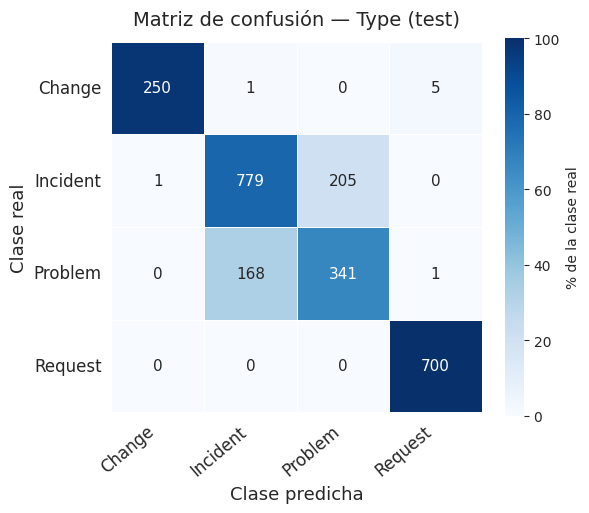

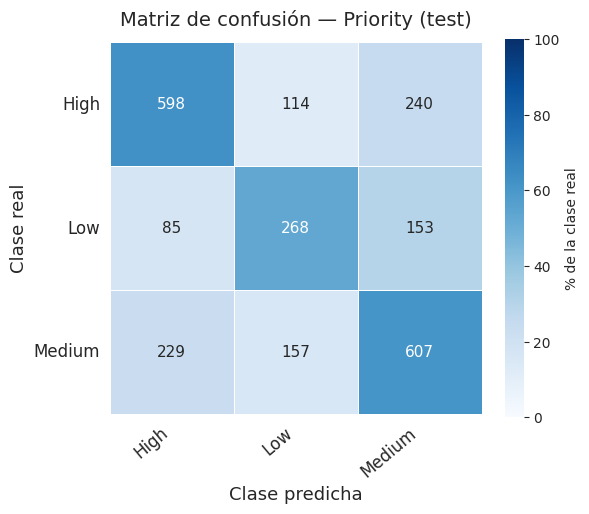

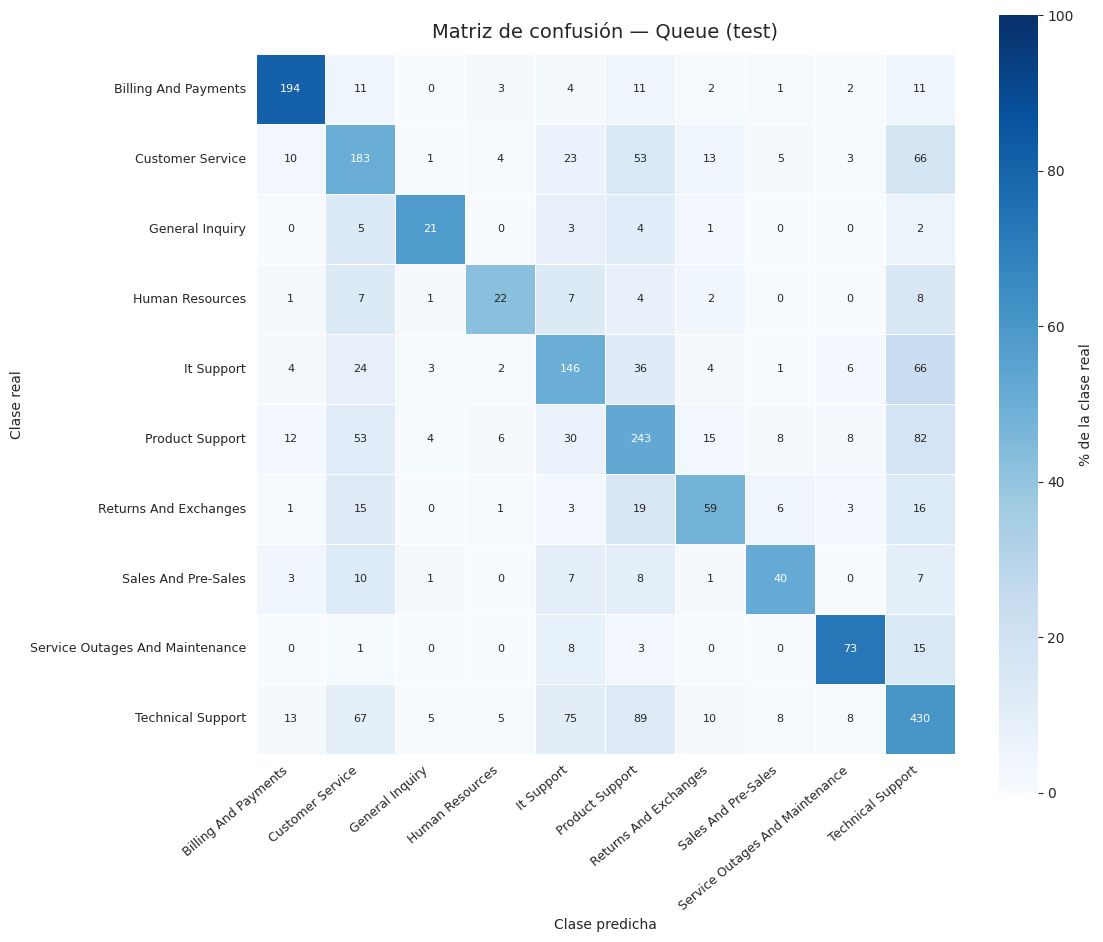

In [106]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_style("white")

for objetivo, resultados in analisis_test.items():

    matriz = resultados["matriz_confusion"]
    modelo = resultados["modelo"]
    n_clases = len(modelo.classes_)

    # Normalizado por fila: color = % de esa clase real que cae en cada predicha
    matriz_pct = matriz.values.astype(float) / matriz.values.sum(axis=1, keepdims=True) * 100

    # Escalado según nº de clases: Queue (10) necesita más espacio y letra más pequeña que Type (2-4)
    tam_figura = max(6, n_clases * 1.15)
    tam_fuente_celda = 11 if n_clases <= 4 else 8
    tam_fuente_ejes = 12 if n_clases <= 4 else 9

    etiquetas = [c.replace("_", " ").title() for c in modelo.classes_]

    fig, ax = plt.subplots(figsize=(tam_figura, tam_figura * 0.85))

    sns.heatmap(
        matriz_pct,
        annot=matriz.values,       # muestra el conteo real dentro de cada celda
        fmt="d",
        cmap="Blues",
        vmin=0, vmax=100,
        xticklabels=etiquetas,
        yticklabels=etiquetas,
        cbar_kws={"label": "% de la clase real"},
        annot_kws={"size": tam_fuente_celda},
        linewidths=0.5, linecolor="white",
        square=True,
        ax=ax
    )

    ax.set_xlabel("Clase predicha", fontsize=tam_fuente_ejes + 1)
    ax.set_ylabel("Clase real", fontsize=tam_fuente_ejes + 1)
    ax.set_title(f"Matriz de confusión — {objetivo.capitalize()} (test)", fontsize=14, pad=12)

    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=tam_fuente_ejes)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=tam_fuente_ejes)

    plt.tight_layout()
    plt.savefig(f"matriz_confusion_{objetivo}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [107]:
for objetivo, resultados in analisis_test.items():

    matriz = resultados["matriz_confusion"].copy()

    errores = []

    for clase_real in matriz.index:
        for clase_predicha in matriz.columns:

            clase_real_limpia = clase_real.replace("Real: ", "")
            clase_predicha_limpia = clase_predicha.replace("Predicha: ", "")

            if clase_real_limpia != clase_predicha_limpia:

                errores.append({
                    "clase_real": clase_real_limpia,
                    "clase_predicha": clase_predicha_limpia,
                    "errores": matriz.loc[clase_real, clase_predicha]
                })

    tabla_errores = pd.DataFrame(errores)

    tabla_errores = tabla_errores[
        tabla_errores["errores"] > 0
    ].sort_values(
        by="errores",
        ascending=False
    ).reset_index(drop=True)

    print(f"CONFUSIONES REALES: {objetivo.upper()}")
    print("=" * 70)

    display(tabla_errores.head(10))

CONFUSIONES REALES: TYPE


,clase_real,clase_predicha,errores
0,incident,problem,205
1,problem,incident,168
2,change,request,5
3,change,incident,1
4,incident,change,1
5,problem,request,1


CONFUSIONES REALES: PRIORITY


,clase_real,clase_predicha,errores
0,high,medium,240
1,medium,high,229
2,medium,low,157
3,low,medium,153
4,high,low,114
5,low,high,85


CONFUSIONES REALES: QUEUE


,clase_real,clase_predicha,errores
0,technical support,product support,89
1,product support,technical support,82
2,technical support,it support,75
3,technical support,customer service,67
4,customer service,technical support,66
5,it support,technical support,66
6,product support,customer service,53
7,customer service,product support,53
8,it support,product support,36
9,product support,it support,30


Hemos visto que las pares de clases se confunden más son: (según el número de errores en ambas direcciones.)

decidimos estudiar:
* Type: incident y problem.
* Priority: high y medium, medium y low, high y low.
* Queue: technical support y product support, technical support y it support, technical support y customer service.

### A. 1. ¿Por qué el modelo confunde estas dos clases? **<->** ^Type: incident y problem

**vamos a mirar qué características del texto comparten y cuáles deberían diferenciarlas.**

asi, podremos saber ¿Los textos de incident y problem contienen señales suficientemente diferentes para que un modelo TF-IDF pueda distinguirlos, o utilizan un lenguaje tan parecido que la distinción resulta difícil?

**1. ^Type: incident ↔ problem**

In [108]:
import numpy as np
import pandas as pd


# 6.1.A - Type: incident vs problem
# Características compartidas y diferenciadoras

config = "con_lem_baja_bigr"

vectorizer = tfidf_vectorizers[config]
X = X_tfidf[config]

# Índices de las dos clases
idx_incident = np.where(y_type.values == "incident")[0]
idx_problem = np.where(y_type.values == "problem")[0]

# Vocabulario
feature_names = np.array(vectorizer.get_feature_names_out())

# Media TF-IDF de cada término dentro de cada clase
media_incident = np.asarray(X[idx_incident].mean(axis=0)).ravel()
media_problem = np.asarray(X[idx_problem].mean(axis=0)).ravel()


# 1. Términos más característicos de cada clase

# Diferencia absoluta y relativa entre clases
diferencia = media_incident - media_problem

tabla_diferencias = pd.DataFrame({
    "termino": feature_names,
    "tfidf_incident": media_incident,
    "tfidf_problem": media_problem,
    "diferencia": diferencia
})

# Términos más característicos de incident
incident_caracteristicos = (
    tabla_diferencias[
        tabla_diferencias["tfidf_incident"] > tabla_diferencias["tfidf_problem"]
    ]
    .sort_values("diferencia", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

# Términos más característicos de problem
problem_caracteristicos = (
    tabla_diferencias[
        tabla_diferencias["tfidf_problem"] > tabla_diferencias["tfidf_incident"]
    ]
    .sort_values("diferencia", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

print("=== Términos más característicos de incident ===")
display(incident_caracteristicos)

print("=== Términos más característicos de problem ===")
display(problem_caracteristicos)


# 2. Términos compartidos por ambas clases

# Consideramos compartido un término que tenga presencia
# apreciable en ambas clases.
umbral_compartido = 0.001

compartidos = pd.DataFrame({
    "termino": feature_names,
    "tfidf_incident": media_incident,
    "tfidf_problem": media_problem
})

compartidos["media"] = (
    compartidos["tfidf_incident"] +
    compartidos["tfidf_problem"]
) / 2

compartidos = (
    compartidos[
        (compartidos["tfidf_incident"] >= umbral_compartido) &
        (compartidos["tfidf_problem"] >= umbral_compartido)
    ]
    .sort_values("media", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

print("Términos más compartidos entre incident y problem ")
display(compartidos)

=== Términos más característicos de incident ===


,termino,tfidf_incident,tfidf_problem,diferencia
0,system,0.038154,0.028362,0.009792
1,incident,0.016541,0.007022,0.009519
2,outage,0.013281,0.004170,0.009112
3,impact,0.018975,0.011223,0.007753
4,affect,0.017065,0.009501,0.007564
5,several,0.011409,0.004081,0.007328
6,service,0.014664,0.007617,0.007047
7,restart,0.022571,0.015631,0.006940
8,recent,0.025369,0.018507,0.006862
9,access,0.024876,0.018494,0.006381


=== Términos más característicos de problem ===


,termino,tfidf_incident,tfidf_problem,diferencia
0,line,0.000115,0.000115,-4.915106e-07
1,datum recently,0.000420,0.000421,-5.145292e-07
2,attempt access,0.001049,0.001050,-6.333390e-07
3,clear temporary,0.000545,0.000546,-8.831665e-07
4,adapt,0.000042,0.000043,-8.838392e-07
5,difficulty project,0.000488,0.000489,-9.448599e-07
6,advise additional,0.000597,0.000598,-9.593879e-07
7,statistic,0.000169,0.000170,-1.013887e-06
8,like schedule,0.000319,0.000320,-1.095182e-06
9,greeting,0.000045,0.000047,-1.186622e-06


Términos más compartidos entre incident y problem 


,termino,tfidf_incident,tfidf_problem,media
0,issue,0.052314,0.050472,0.051393
1,problem,0.039908,0.042994,0.041451
2,system,0.038154,0.028362,0.033258
3,datum,0.028867,0.033499,0.031183
4,software,0.032702,0.029603,0.031153
5,resolve,0.031283,0.028973,0.030128
6,update,0.030944,0.029112,0.030028
7,due,0.028018,0.030687,0.029352
8,security,0.025954,0.026655,0.026304
9,recent,0.025369,0.018507,0.021938


2.

In [109]:
import pandas as pd
import re

# Seleccionar tickets similares de incident y problem

# Palabras comunes relevantes observadas en el análisis TF-IDF
terminos_comunes = [
    "issue",
    "problem",
    "system",
    "software",
    "resolve",
    "update",
    "security",
    "access",
    "support",
    "server",
    "cause",
    "restart"
]

# Trabajamos sobre el texto original
df_muestra = df_tf_idf.copy()

# Unimos Subject + Body
df_muestra["texto_analisis"] = (
    df_muestra["subject"].fillna("") + " " +
    df_muestra["body"].fillna("")
).str.lower()

# Contar cuántos términos comunes contiene cada ticket
def contar_terminos(texto):
    return sum(
        len(re.findall(r"\b" + re.escape(termino) + r"\b", texto))
        for termino in terminos_comunes
    )

df_muestra["num_terminos_comunes"] = (
    df_muestra["texto_analisis"]
    .apply(contar_terminos)
)

# Quedarnos solo con incident y problem
df_muestra = df_muestra[
    df_muestra["type"].isin(["incident", "problem"])
].copy()


# Seleccionar los 10 tickets de cada clase con más
# vocabulario común

muestra_incident = (
    df_muestra[df_muestra["type"] == "incident"]
    .sort_values("num_terminos_comunes", ascending=False)
    .head(10)
)

muestra_problem = (
    df_muestra[df_muestra["type"] == "problem"]
    .sort_values("num_terminos_comunes", ascending=False)
    .head(10)
)

# Unir las dos muestras
muestra_final = pd.concat(
    [muestra_incident, muestra_problem]
)[
    ["type", "subject", "body", "num_terminos_comunes"]
]

# Mostrar
display(muestra_final.reset_index(drop=True))

,type,subject,body,num_terminos_comunes
0,incident,concern system security,dear customer support reporting potential secu...,18
1,incident,problem system access,customer support unauthorized access alert tri...,17
2,incident,concern regarding potential security breach ho...,customer support reporting possible security b...,16
3,incident,issue recent system update causing software in...,regret inconvenience caused software incompati...,15
4,incident,problem system performance today,regarding issue system crashes slow performanc...,15
5,incident,report potential security breach,customer support reporting potential security ...,15
6,incident,update platform downtime issue,dear customer support reporting incident invol...,14
7,incident,healthcare provider system issue,customer support n ni reporting issue healthca...,14
8,incident,concern regarding security medical data,customer support encountering issue security m...,14
9,incident,seriousness security breach hospital system,customer support preparing report security bre...,14


### A. 1. ¿Por qué el modelo confunde estas dos clases? **<->** ^Priority: high y medium, medium y low, high y low.

Usamos la representación TF-IDF que corresponde al mejor modelo de Priority: sin_lem_baja_bigr.

In [110]:
import numpy as np
import pandas as pd


# 6.1.A - Priority
# Características compartidas y diferenciadoras

config = "sin_lem_baja_bigr"

vectorizer = tfidf_vectorizers[config]
X = X_tfidf[config]

feature_names = np.array(vectorizer.get_feature_names_out())


def analizar_par_priority(clase_1, clase_2, top_n=30):

    # Índices de cada clase
    idx_1 = np.where(y_priority.values == clase_1)[0]
    idx_2 = np.where(y_priority.values == clase_2)[0]

    # TF-IDF medio de cada término
    media_1 = np.asarray(X[idx_1].mean(axis=0)).ravel()
    media_2 = np.asarray(X[idx_2].mean(axis=0)).ravel()

    diferencia = media_1 - media_2

    tabla = pd.DataFrame({
        "termino": feature_names,
        f"tfidf_{clase_1}": media_1,
        f"tfidf_{clase_2}": media_2,
        "diferencia": diferencia
    })


    # Términos característicos de cada clase

    caracteristicos_1 = (
        tabla[tabla[f"tfidf_{clase_1}"] > tabla[f"tfidf_{clase_2}"]]
        .sort_values("diferencia", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    caracteristicos_2 = (
        tabla[tabla[f"tfidf_{clase_2}"] > tabla[f"tfidf_{clase_1}"]]
        .sort_values("diferencia", ascending=True)
        .head(top_n)
        .reset_index(drop=True)
    )

    # Términos compartidos

    compartidos = tabla.copy()

    compartidos["media"] = (
        compartidos[f"tfidf_{clase_1}"] +
        compartidos[f"tfidf_{clase_2}"]
    ) / 2

    compartidos = (
        compartidos[
            (compartidos[f"tfidf_{clase_1}"] >= 0.001) &
            (compartidos[f"tfidf_{clase_2}"] >= 0.001)
        ]
        .sort_values("media", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    print(f"\n{'=' * 70}")
    print(f"PRIORITY: {clase_1.upper()} ↔ {clase_2.upper()}")
    print(f"{'=' * 70}")

    print(f"\n Términos más característicos de {clase_1.upper()}-")
    display(caracteristicos_1)

    print(f"\n Términos más característicos de {clase_2.upper()} ")
    display(caracteristicos_2)

    print(f"\n Términos compartidos ")
    display(compartidos)

    return {
        "caracteristicos_1": caracteristicos_1,
        "caracteristicos_2": caracteristicos_2,
        "compartidos": compartidos,
        "tabla_completa": tabla
    }


# Analizar los tres pares de Priority
resultados_priority = {}

resultados_priority["high_medium"] = analizar_par_priority(
    "high", "medium"
)

resultados_priority["medium_low"] = analizar_par_priority(
    "medium", "low"
)

resultados_priority["high_low"] = analizar_par_priority(
    "high", "low"
)


PRIORITY: HIGH ↔ MEDIUM

 Términos más característicos de HIGH-


,termino,tfidf_high,tfidf_medium,diferencia
0,system,0.025072,0.016414,0.008657
1,outage,0.007464,0.001934,0.005530
2,service,0.009746,0.004361,0.005385
3,critical,0.007069,0.002502,0.004567
4,urgent,0.006617,0.002775,0.003842
5,server,0.012997,0.009299,0.003698
6,disruptions,0.007956,0.004302,0.003653
7,crashes,0.007859,0.004207,0.003652
8,outages,0.006284,0.002712,0.003572
9,updates,0.015172,0.011676,0.003495



 Términos más característicos de MEDIUM 


,termino,tfidf_high,tfidf_medium,diferencia
0,strategies,0.013437,0.018265,-0.004828
1,details,0.008346,0.012222,-0.003876
2,billing,0.009339,0.012436,-0.003097
3,information,0.017114,0.020051,-0.002937
4,integration,0.017835,0.020760,-0.002925
5,digital strategies,0.005960,0.008779,-0.002819
6,could provide,0.008039,0.010724,-0.002686
7,features,0.005648,0.008318,-0.002670
8,interested,0.005301,0.007950,-0.002649
9,provide details,0.003944,0.006562,-0.002618



 Términos compartidos 


...

,termino,tfidf_high,tfidf_low,diferencia
0,system,0.025072,0.014941,0.010131
1,server,0.012997,0.006551,0.006447
2,outage,0.007464,0.001167,0.006297
3,crashes,0.007859,0.001915,0.005944
4,critical,0.007069,0.001189,0.005880
5,breach,0.013404,0.008328,0.005076
6,outages,0.006284,0.001224,0.005060
7,downtime,0.005590,0.000613,0.004977
8,service,0.009746,0.004870,0.004876
9,overload,0.007207,0.002543,0.004665



 Términos más característicos de LOW 


,termino,tfidf_high,tfidf_low,diferencia
0,details,0.008346,0.014806,-0.006460
1,integration,0.017835,0.022867,-0.005032
2,information,0.017114,0.022045,-0.004931
3,options,0.003420,0.008342,-0.004922
4,could,0.018527,0.022778,-0.004251
5,thank,0.008351,0.012240,-0.003890
6,provide details,0.003944,0.007628,-0.003684
7,project,0.016356,0.019869,-0.003513
8,available,0.005745,0.009080,-0.003335
9,dashboard,0.001834,0.005136,-0.003302



 Términos compartidos 


,termino,tfidf_high,tfidf_low,diferencia,media
0,data,0.040742,0.040746,-0.000004,0.040744
1,security,0.025961,0.026069,-0.000109,0.026015
2,issue,0.026141,0.023863,0.002279,0.025002
3,support,0.022432,0.022791,-0.000359,0.022611
4,software,0.023291,0.021325,0.001967,0.022308
5,would,0.020527,0.023630,-0.003103,0.022078
6,medical,0.020821,0.022669,-0.001848,0.021745
7,analytics,0.022447,0.020377,0.002070,0.021412
8,digital,0.021029,0.020461,0.000568,0.020745
9,assistance,0.020748,0.020630,0.000118,0.020689


2. e.g.s reales de priority

In [111]:
# Términos compartidos entre las categorías de Priority
terminos_comunes_priority = [
    "data", "security", "issue", "support", "software",
    "problem", "information", "project", "customer",
    "system", "digital", "integration", "assistance"
]

df_priority_ejemplos = df_tf_idf[
    ["subject", "body", "Tags", "priority"]
].copy()

# Convertir Tags (lista) a texto
df_priority_ejemplos["tags_text"] = (
    df_priority_ejemplos["Tags"]
    .apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
)

# Construir texto completo
df_priority_ejemplos["text_combined"] = (
    df_priority_ejemplos["subject"].fillna("").astype(str) + " " +
    df_priority_ejemplos["body"].fillna("").astype(str) + " " +
    df_priority_ejemplos["tags_text"].fillna("").astype(str)
).str.lower()

# Contar términos comunes presentes
df_priority_ejemplos["n_terminos_comunes"] = (
    df_priority_ejemplos["text_combined"]
    .apply(
        lambda x: sum(
            termino in x
            for termino in terminos_comunes_priority
        )
    )
)

# Seleccionar 10 ejemplos con mayor solapamiento por clase
ejemplos_priority = (
    df_priority_ejemplos
    .sort_values(
        ["priority", "n_terminos_comunes"],
        ascending=[True, False]
    )
    .groupby("priority")
    .head(10)
)

# Mostrar ejemplos
for prioridad in ["high", "medium", "low"]:
    print(f"PRIORITY: {prioridad.upper()}")

    ejemplos = ejemplos_priority[
        ejemplos_priority["priority"] == prioridad
    ]

    for i, (_, fila) in enumerate(ejemplos.iterrows(), 1):
        print(f"\n Ejemplo {i} ")
        print(fila["text_combined"])

PRIORITY: HIGH

 Ejemplo 1 
reported data integration failures dear customer support documenting issues related data integration failures across various analytics platforms considerably hindered investment optimization processes appears problems started following recent updates products indicating possible incompatibility issue despite attempts system reboots applying software patches issue remains unresolved failures caused operational inefficiencies could potentially lead financial setbacks prompt attention matter would highly appreciated kindly request urgent assistance resolving issue bug performance disruption recovery maintenance security

 Ejemplo 2 
reported security concern healthcare data system dear customer support hospital healthcare data management system experienced unauthorized access attempts suspect may due outdated software patches attempted address issue applying patches updating vpn router strengthening firewall configurations measures not resolved problem worried 

### A. 1. ¿Por qué el modelo confunde estas dos clases? **<->** ^Queue: technical support y product support, technical support y it support, technical support y customer service.


In [112]:
import numpy as np

config = "sin_lem_baja_bigr"

vectorizer = tfidf_vectorizers[config]
X = X_tfidf[config]

terminos = np.array(vectorizer.get_feature_names_out())

pares_queue = [
    ("technical support", "product support"),
    ("technical support", "it support"),
    ("technical support", "customer service")
]

for clase_a, clase_b in pares_queue:

    print(f"{clase_a.upper()}  <->  {clase_b.upper()}")

    # Convertir explícitamente a boolean de NumPy
    idx_a = (
        df_tf_idf["queue"]
        .to_numpy()
        == clase_a
    )

    idx_b = (
        df_tf_idf["queue"]
        .to_numpy()
        == clase_b
    )

    # Media TF-IDF por clase
    media_a = np.asarray(
        X[idx_a].mean(axis=0)
    ).ravel()

    media_b = np.asarray(
        X[idx_b].mean(axis=0)
    ).ravel()

    # Diferencia entre clases
    diferencia = media_a - media_b

    # Términos más característicos de cada clase
    top_a = np.argsort(diferencia)[::-1][:30]
    top_b = np.argsort(diferencia)[:30]

    print(f"\n--- Términos más característicos de {clase_a} ---")

    for i in top_a:
        print(
            f"{terminos[i]:40s} "
            f"{media_a[i]:.4f}"
        )

    print(f"\n--- Términos más característicos de {clase_b} ---")

    for i in top_b:
        print(
            f"{terminos[i]:40s} "
            f"{media_b[i]:.4f}"
        )

    # Términos compartidos entre las dos clases
    top_n = 100

    top_a_100 = set(
        np.argsort(media_a)[-top_n:]
    )

    top_b_100 = set(
        np.argsort(media_b)[-top_n:]
    )

    compartidos = top_a_100.intersection(top_b_100)

    # Ordenar por importancia media
    compartidos_ordenados = sorted(
        compartidos,
        key=lambda i: (
            media_a[i] + media_b[i]
        ) / 2,
        reverse=True
    )

    print("\n Términos compartidos entre ambas clases")

    for i in compartidos_ordenados[:30]:
        media = (
            media_a[i] + media_b[i]
        ) / 2

        print(
            f"{terminos[i]:40s} "
            f"A={media_a[i]:.4f} | "
            f"B={media_b[i]:.4f} | "
            f"media={media:.4f}"
        )

TECHNICAL SUPPORT  <->  PRODUCT SUPPORT

--- Términos más característicos de technical support ---
system                                   0.0242
software                                 0.0283
network                                  0.0129
problem                                  0.0253
issue                                    0.0311
devices                                  0.0123
restarting                               0.0143
server                                   0.0136
technical                                0.0075
breach                                   0.0169
connectivity                             0.0092
platform                                 0.0166
updates                                  0.0169
persists                                 0.0123
downtime                                 0.0051
issues                                   0.0212
data breach                              0.0098
still                                    0.0118
website                              

In [113]:
# Términos compartidos entre las categorías de Queue
terminos_comunes_queue = [
    "issue", "problem", "support", "software", "system",
    "data", "security", "access", "update", "technical",
    "application", "network", "customer", "service",
    "information", "integration", "device"
]

# Clases que vamos a comparar
clases_queue = [
    "technical support",
    "product support",
    "it support",
    "customer service"
]

df_queue_ejemplos = df_tf_idf[
    ["subject", "body", "Tags", "queue"]
].copy()

# Convertir Tags (listas) a texto
df_queue_ejemplos["tags_text"] = (
    df_queue_ejemplos["Tags"]
    .apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
)

# Construir texto completo
df_queue_ejemplos["text_combined"] = (
    df_queue_ejemplos["subject"].fillna("").astype(str) + " " +
    df_queue_ejemplos["body"].fillna("").astype(str) + " " +
    df_queue_ejemplos["tags_text"].fillna("").astype(str)
).str.lower()

# Contar términos compartidos presentes en cada ticket
df_queue_ejemplos["n_terminos_comunes"] = (
    df_queue_ejemplos["text_combined"]
    .apply(
        lambda x: sum(
            termino in x
            for termino in terminos_comunes_queue
        )
    )
)

# Seleccionar los 10 tickets con mayor solapamiento léxico por clase
ejemplos_queue = (
    df_queue_ejemplos[
        df_queue_ejemplos["queue"].isin(clases_queue)
    ]
    .sort_values(
        ["queue", "n_terminos_comunes"],
        ascending=[True, False]
    )
    .groupby("queue")
    .head(10)
)

# Mostrar los ejemplos
for cola in clases_queue:
    print(f"QUEUE: {cola.upper()}")

    ejemplos = ejemplos_queue[
        ejemplos_queue["queue"] == cola
    ]

    for i, (_, fila) in enumerate(ejemplos.iterrows(), 1):
        print(f"\n Ejemplo {i} ")
        print(fila["text_combined"])

QUEUE: TECHNICAL SUPPORT

 Ejemplo 1 
 customer support received report healthcare provider experiencing multiple hardware software failures issues impacting secure access medical data suspected recent system update may caused conflicts resulting problems team attempted resolve issue restarting affected services devices well applying recommended patches unfortunately efforts not resulted resolution kindly request assistance resolve issue promptly ensure uninterrupted access hardware software security it tech support

 Ejemplo 2 
 customer support team reports multiple software hardware malfunctions encountered healthcare provider issues impacting secure access medical data suspected recent system update may caused conflicts resulting problems team attempted resolve issue restarting affected services devices well applying recommended patches unfortunately efforts not yet resolved problem kindly request assistance resolve matter soon possible ensure continuous operation bug hardware secu

### B. tickets mal clasificados para identificar patrones
### B1. Longitud del ticket

In [114]:
import numpy as np
import pandas as pd

posiciones = {
    "type": pos_test_type,
    "priority": pos_test_priority,
    "queue": pos_test_queue
}

def analizar_longitud(objetivo):

    y_real = np.asarray(analisis_test[objetivo]["y_test"])
    y_pred = np.asarray(analisis_test[objetivo]["y_pred"])

    df = df_tf_idf.iloc[posiciones[objetivo]].copy()

    # Convertimos a texto para evitar problemas con NaN u otros tipos
    subject = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)
    tags = df["Tags"].fillna("").astype(str)

    datos = pd.DataFrame({
        "correcto": y_real == y_pred,
        "subject_words": subject.str.split().str.len().to_numpy(),
        "body_words": body.str.split().str.len().to_numpy(),
        "tags_words": tags.str.split().str.len().to_numpy()
    })

    datos["total_words"] = (
        datos["subject_words"]
        + datos["body_words"]
        + datos["tags_words"]
    )

    print(objetivo.upper())

    print("\n Medianas")
    print(
        datos.groupby("correcto")[
            ["subject_words", "body_words", "tags_words", "total_words"]
        ].median()
    )

    print("\n Medias")
    print(
        datos.groupby("correcto")[
            ["subject_words", "body_words", "tags_words", "total_words"]
        ].mean()
    )

    print("\n Percentiles ")
    print(
        datos.groupby("correcto")[
            ["subject_words", "body_words", "tags_words", "total_words"]
        ].quantile([0.25, 0.50, 0.75, 0.90, 0.99])
    )

    return datos


datos_type = analizar_longitud("type")
datos_priority = analizar_longitud("priority")
datos_queue = analizar_longitud("queue")

TYPE

 Medianas
          subject_words  body_words  tags_words  total_words
correcto                                                    
False               4.0        32.0         5.0         41.0
True                4.0        35.0         5.0         44.0

 Medias
          subject_words  body_words  tags_words  total_words
correcto                                                    
False          3.973753   32.745407    5.278215    41.997375
True           3.964734   34.176812    5.103382    43.244928

 Percentiles 
               subject_words  body_words  tags_words  total_words
correcto                                                         
False    0.25            3.0        19.0         5.0         27.0
         0.50            4.0        32.0         5.0         41.0
         0.75            5.0        49.0         6.0         58.0
         0.90            6.0        53.0         7.0         63.0
         0.99            9.2        59.2         8.0         69.0
True     0

### B2. Información disponible por campo

In [115]:
import numpy as np
import pandas as pd

posiciones = {
    "type": pos_test_type,
    "priority": pos_test_priority,
    "queue": pos_test_queue
}

def analizar_informacion(objetivo):

    y_real = np.asarray(analisis_test[objetivo]["y_test"])
    y_pred = np.asarray(analisis_test[objetivo]["y_pred"])

    df = df_tf_idf.iloc[posiciones[objetivo]].copy()

    subject = df["subject"].fillna("").astype(str).str.strip()
    body = df["body"].fillna("").astype(str).str.strip()
    tags = df["Tags"].fillna("").astype(str).str.strip()

    datos = pd.DataFrame({
        "correcto": y_real == y_pred,
        "subject_disponible": subject.ne(""),
        "body_disponible": body.ne(""),
        "tags_disponibles": tags.ne(""),
        "num_tags": tags.str.split().str.len()
    })

    print(objetivo.upper())

    # Porcentaje de tickets con cada campo disponible
    print("\n Campos disponibles (%) ")

    resumen = datos.groupby("correcto")[
        ["subject_disponible", "body_disponible", "tags_disponibles"]
    ].mean() * 100

    print(resumen.round(2))

    # Cantidad de Tags
    print("\n Cantidad de Tags ")

    print(
        datos.groupby("correcto")["num_tags"]
        .agg(["mean", "median", "min", "max"])
        .round(2)
    )

    return datos


datos_info_type = analizar_informacion("type")
datos_info_priority = analizar_informacion("priority")
datos_info_queue = analizar_informacion("queue")

TYPE

 Campos disponibles (%) 
          subject_disponible  body_disponible  tags_disponibles
correcto                                                       
False                  88.98            100.0             100.0
True                   82.46            100.0             100.0

 Cantidad de Tags 
          mean  median  min  max
correcto                        
False     5.28     5.0    2   10
True      5.10     5.0    1   10
PRIORITY

 Campos disponibles (%) 
          subject_disponible  body_disponible  tags_disponibles
correcto                                                       
False                  88.55            100.0             100.0
True                   80.72            100.0             100.0

 Cantidad de Tags 
          mean  median  min  max
correcto                        
False     5.02     5.0    1    9
True      5.22     5.0    1   10
QUEUE

 Campos disponibles (%) 
          subject_disponible  body_disponible  tags_disponibles
correcto              

### B3. Coherencia entre campos

Estudiaremos si los campos se contradicen entre si:

### **.1 Entrenamiento, validacion**

* Entrenamos los 9 modelos
* Predecimos sobre validation.
* Calculamos métricas de cada modelo individual.
* Creamos la variable coherencia/coincidencias por ticket a partir de Subject, Body y Tags.

**Entrenamos**

In [116]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC


# 1. Stopwords
stop_words_tfidf = stop_words_standard - stop_words_keep


# 2. Configuración de cada objetivo
config_b3 = {
    "type": {
        "min_df": 20,
        "ngram_range": (1, 2),
        "C": 1,
        "threshold_tags": 201,
        "lemmatized": True
    },
    "priority": {
        "min_df": 20,
        "ngram_range": (1, 2),
        "C": 1,
        "threshold_tags": 201,
        "lemmatized": False
    },
    "queue": {
        "min_df": 20,
        "ngram_range": (1, 2),
        "C": 10,
        "threshold_tags": 1000,
        "lemmatized": False
    }
}


# 3. Textos de Subject y Body
df_base = df_tf_idf.copy()
df_lem = df_tf_idf_lem.copy()

textos = {
    "subject": {
        "normal": df_base["subject"].fillna("").astype(str),
        "lem": df_lem["subject"].fillna("").astype(str)
    },
    "body": {
        "normal": df_base["body"].fillna("").astype(str),
        "lem": df_lem["body"].fillna("").astype(str)
    }
}


# 4. Tags
tags_b3 = {
    201: df_tags[201]["Tags"].fillna("").astype(str),
    1000: df_tags[1000]["Tags"].fillna("").astype(str)
}


# 5. Targets y particiones
targets = {
    "type": y_type,
    "priority": y_priority,
    "queue": y_queue
}

posiciones = {
    "type": {
        "train": df_base.index.get_indexer(idx_train_type)
    },
    "priority": {
        "train": df_base.index.get_indexer(idx_train_priority)
    },
    "queue": {
        "train": df_base.index.get_indexer(idx_train_queue)
    }
}

# 6. Función de entrenamiento
def entrenar_campo(textos_campo, objetivo, campo):

    config = config_b3[objetivo]

    # Selección de lematización
    if campo != "Tags":
        clave = "lem" if config["lemmatized"] else "normal"
        textos_campo = textos_campo[clave]

    # Datos de entrenamiento
    pos_train = posiciones[objetivo]["train"]

    texto_train = textos_campo.iloc[pos_train]
    y_train = targets[objetivo].iloc[pos_train]

    # TF-IDF
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words=list(stop_words_tfidf),
        min_df=config["min_df"],
        ngram_range=config["ngram_range"]
    )

    X_train = vectorizer.fit_transform(texto_train)

    # Linear SVC
    modelo = LinearSVC(
        C=config["C"],
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    return {
        "modelo": modelo,
        "vectorizer": vectorizer,
        "X_train": X_train
    }


# 7. Entrenamiento de los 9 modelos
modelos_b3 = {}

for objetivo in ["type", "priority", "queue"]:

    print("\n" + "=" * 80)
    print(f"OBJETIVO: {objetivo.upper()}")
    print("=" * 80)

    modelos_b3[objetivo] = {}

    # Subject
    print("\nEntrenando SUBJECT...")

    modelos_b3[objetivo]["subject"] = entrenar_campo(
        textos["subject"],
        objetivo,
        "subject"
    )

    print(
        "Dimensiones:",
        modelos_b3[objetivo]["subject"]["X_train"].shape
    )

    # Body
    print("\nEntrenando BODY...")

    modelos_b3[objetivo]["body"] = entrenar_campo(
        textos["body"],
        objetivo,
        "body"
    )

    print(
        "Dimensiones:",
        modelos_b3[objetivo]["body"]["X_train"].shape
    )

    # Tags
    threshold = config_b3[objetivo]["threshold_tags"]

    print(f"\nEntrenando TAGS (umbral {threshold})...")

    modelos_b3[objetivo]["Tags"] = entrenar_campo(
        tags_b3[threshold],
        objetivo,
        "Tags"
    )

    print(
        "Dimensiones:",
        modelos_b3[objetivo]["Tags"]["X_train"].shape
    )


print("ENTRENAMIENTO B3 FINALIZADO")



OBJETIVO: TYPE

Entrenando SUBJECT...
Dimensiones: (11436, 509)

Entrenando BODY...
Dimensiones: (11436, 4066)

Entrenando TAGS (umbral 201)...
Dimensiones: (11436, 280)

OBJETIVO: PRIORITY

Entrenando SUBJECT...
Dimensiones: (11436, 506)

Entrenando BODY...
Dimensiones: (11436, 4151)

Entrenando TAGS (umbral 201)...
Dimensiones: (11436, 280)

OBJETIVO: QUEUE

Entrenando SUBJECT...
Dimensiones: (11436, 502)

Entrenando BODY...
Dimensiones: (11436, 4129)

Entrenando TAGS (umbral 1000)...
Dimensiones: (11436, 274)
ENTRENAMIENTO B3 FINALIZADO


**Predecimos sobre validation.**

In [117]:
# PREDICCIONES B3 SOBRE VALIDATION

predicciones_b3_val = {}

pos_val = {
    "type": df_base.index.get_indexer(idx_val_type),
    "priority": df_base.index.get_indexer(idx_val_priority),
    "queue": df_base.index.get_indexer(idx_val_queue)
}

for objetivo in ["type", "priority", "queue"]:

    print(f"PREDICCIONES VALIDATION: {objetivo.upper()}")

    predicciones_b3_val[objetivo] = {}

    posiciones_val = pos_val[objetivo]
    config = config_b3[objetivo]

    # SUBJECT

    vectorizer = modelos_b3[objetivo]["subject"]["vectorizer"]
    modelo = modelos_b3[objetivo]["subject"]["modelo"]

    if config["lemmatized"]:
        texto_subject = textos["subject"]["lem"]
    else:
        texto_subject = textos["subject"]["normal"]

    X_val_subject = vectorizer.transform(
        texto_subject.iloc[posiciones_val]
    )

    predicciones_b3_val[objetivo]["subject"] = (
        modelo.predict(X_val_subject)
    )

    print(
        "Subject:",
        len(predicciones_b3_val[objetivo]["subject"]),
        "predicciones"
    )

    # BODY

    vectorizer = modelos_b3[objetivo]["body"]["vectorizer"]
    modelo = modelos_b3[objetivo]["body"]["modelo"]

    if config["lemmatized"]:
        texto_body = textos["body"]["lem"]
    else:
        texto_body = textos["body"]["normal"]

    X_val_body = vectorizer.transform(
        texto_body.iloc[posiciones_val]
    )

    predicciones_b3_val[objetivo]["body"] = (
        modelo.predict(X_val_body)
    )

    print(
        "Body:",
        len(predicciones_b3_val[objetivo]["body"]),
        "predicciones"
    )

    # TAGS

    vectorizer = modelos_b3[objetivo]["Tags"]["vectorizer"]
    modelo = modelos_b3[objetivo]["Tags"]["modelo"]

    threshold = config["threshold_tags"]

    texto_tags = tags_b3[threshold]

    X_val_tags = vectorizer.transform(
        texto_tags.iloc[posiciones_val]
    )

    predicciones_b3_val[objetivo]["Tags"] = (
        modelo.predict(X_val_tags)
    )

    print(
        "Tags:",
        len(predicciones_b3_val[objetivo]["Tags"]),
        "predicciones"
    )


print("PREDICCIONES B3 EN VALIDATION FINALIZADAS")

PREDICCIONES VALIDATION: TYPE
Subject: 2451 predicciones
Body: 2451 predicciones
Tags: 2451 predicciones
PREDICCIONES VALIDATION: PRIORITY
Subject: 2451 predicciones
Body: 2451 predicciones
Tags: 2451 predicciones
PREDICCIONES VALIDATION: QUEUE
Subject: 2451 predicciones
Body: 2451 predicciones
Tags: 2451 predicciones
PREDICCIONES B3 EN VALIDATION FINALIZADAS


### **.2 metricas, creación variable coincidencias**

Comparamos el rendimiento de los modelos individuales con el LinearSVC principal de cada objetivo.

Esto nos permite saber, por ejemplo, si Body aporta mucha más capacidad predictiva que Subject o Tags.

**métricas**

In [118]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# MÉTRICAS B3 SOBRE VALIDATION

metricas_b3 = []

for objetivo in ["type", "priority", "queue"]:

    # Etiquetas reales de validation
    y_val = targets[objetivo].iloc[
        pos_val[objetivo]
    ].to_numpy()

    for campo in ["subject", "body", "Tags"]:

        y_pred = predicciones_b3_val[objetivo][campo]

        metricas_b3.append({
            "objetivo": objetivo,
            "campo": campo,
            "accuracy": accuracy_score(y_val, y_pred),
            "precision_macro": precision_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            ),
            "recall_macro": recall_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            ),
            "f1_macro": f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            )
        })


# DataFrame final
metricas_b3 = pd.DataFrame(metricas_b3)

# Ordenar por objetivo y F1
metricas_b3 = metricas_b3.sort_values(
    ["objetivo", "f1_macro"],
    ascending=[True, False]
).reset_index(drop=True)


print("MÉTRICAS B3 - VALIDATION")

print(
    metricas_b3.round(4).to_string(index=False)
)

MÉTRICAS B3 - VALIDATION
objetivo   campo  accuracy  precision_macro  recall_macro  f1_macro
priority    body    0.5716           0.5580        0.5607    0.5592
priority subject    0.4227           0.4018        0.3998    0.3968
priority    Tags    0.4206           0.3917        0.3891    0.3893
   queue    body    0.5512           0.5382        0.5644    0.5495
   queue subject    0.2819           0.2529        0.2875    0.2435
   queue    Tags    0.2836           0.2563        0.2915    0.2415
    type    body    0.8503           0.8584        0.8596    0.8590
    type subject    0.6548           0.6524        0.6143    0.6272
    type    Tags    0.6716           0.6108        0.6242    0.6053


El resultado indica que la información predictiva está principalmente en Body, mientras que Subject y Tags, aislados, son mucho más débiles.

**crear variable Coincidencia**

In [119]:
# COINCIDENCIAS / COHERENCIA ENTRE CAMPOS - VALIDATION

def calcular_coincidencias(row):
    predicciones = [
        row["pred_subject"],
        row["pred_body"],
        row["pred_tags"]
    ]

    n_unicas = len(set(predicciones))

    if n_unicas == 1:
        return 3
    elif n_unicas == 2:
        return 2
    else:
        return 1


coincidencias_b3 = {}

for objetivo in ["type", "priority", "queue"]:

    coincidencias_b3[objetivo] = pd.DataFrame({
        "real": targets[objetivo].iloc[
            pos_val[objetivo]
        ].to_numpy(),

        "pred_subject": predicciones_b3_val[objetivo]["subject"],

        "pred_body": predicciones_b3_val[objetivo]["body"],

        "pred_tags": predicciones_b3_val[objetivo]["Tags"]
    })

    # Número de predicciones que coinciden entre sí
    coincidencias_b3[objetivo]["coincidencias"] = (
        coincidencias_b3[objetivo]
        .apply(calcular_coincidencias, axis=1)
    )


# Resumen de coincidencias

for objetivo in ["type", "priority", "queue"]:

    print("\n" + "=" * 80)
    print(f"COINCIDENCIAS ENTRE CAMPOS - {objetivo.upper()}")
    print("=" * 80)

    resumen = (
        coincidencias_b3[objetivo]["coincidencias"]
        .value_counts(normalize=True)
        .sort_index(ascending=False)
        * 100
    )

    print(
        resumen.rename({
            3: "3 coincidencias",
            2: "2 coincidencias",
            1: "1 coincidencia"
        }).round(2)
    )


COINCIDENCIAS ENTRE CAMPOS - TYPE
coincidencias
3 coincidencias    50.22
2 coincidencias    44.92
1 coincidencia      4.86
Name: proportion, dtype: float64

COINCIDENCIAS ENTRE CAMPOS - PRIORITY
coincidencias
3 coincidencias    21.79
2 coincidencias    63.97
1 coincidencia     14.24
Name: proportion, dtype: float64

COINCIDENCIAS ENTRE CAMPOS - QUEUE
coincidencias
3 coincidencias    13.06
2 coincidencias    41.57
1 coincidencia     45.37
Name: proportion, dtype: float64


### **.3 comparacion con metricas en el modelo principal**

El objetivo es poder ver, para cada objetivo, cuánto aporta cada campo por separado frente al modelo combinado.

In [120]:
# B3.3 — PREDICCIONES DEL MODELO PRINCIPAL EN VALIDATION

config_mejor = {
    "type": {
        "umbral": 201,
        "idx_val": pos_val_type
    },
    "priority": {
        "umbral": 201,
        "idx_val": pos_val_priority
    },
    "queue": {
        "umbral": 1000,
        "idx_val": pos_val_queue
    }
}

pred_principal_val = {}

for objetivo, config in config_mejor.items():

    modelo = modelos_tags_svm[objetivo][config["umbral"]]
    X_val = X_tfidf_tags[config["umbral"]][config["idx_val"]]

    pred_principal_val[objetivo] = modelo.predict(X_val)

    print(
        objetivo,
        len(pred_principal_val[objetivo]),
        pred_principal_val[objetivo][:5]
    )

type 2451 ['incident' 'request' 'change' 'incident' 'incident']
priority 2451 ['low' 'medium' 'high' 'high' 'high']
queue 2451 ['technical support' 'technical support' 'technical support'
 'technical support' 'product support']


In [121]:
# B3.3 — COMPARACIÓN DE MÉTRICAS CON EL MODELO PRINCIPAL

metricas_principal_b3 = []

for objetivo in ["type", "priority", "queue"]:

    idx_val = (
        pos_val_type if objetivo == "type"
        else pos_val_priority if objetivo == "priority"
        else pos_val_queue
    )

    y_real = (
        y_type.iloc[idx_val]
        if objetivo == "type"
        else y_priority.iloc[idx_val]
        if objetivo == "priority"
        else y_queue.iloc[idx_val]
    )

    y_pred = pred_principal_val[objetivo]

    metricas_principal_b3.append({
        "objetivo": objetivo,
        "campo": "modelo_principal",
        "accuracy": accuracy_score(
            y_real, y_pred
        ),
        "precision_macro": precision_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

metricas_principal_b3 = pd.DataFrame(metricas_principal_b3)

comparacion_metricas_b3 = pd.concat(
    [
        metricas_principal_b3,
        metricas_b3
    ],
    ignore_index=True
)

comparacion_metricas_b3 = (
    comparacion_metricas_b3
    .sort_values(
        ["objetivo", "f1_macro"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print("B3.3 — COMPARACIÓN DE MÉTRICAS EN VALIDATION")

print(
    comparacion_metricas_b3.round(4).to_string(index=False)
)

B3.3 — COMPARACIÓN DE MÉTRICAS EN VALIDATION
objetivo            campo  accuracy  precision_macro  recall_macro  f1_macro
priority modelo_principal    0.6161           0.6027        0.6014    0.6020
priority             body    0.5716           0.5580        0.5607    0.5592
priority          subject    0.4227           0.4018        0.3998    0.3968
priority             Tags    0.4206           0.3917        0.3891    0.3893
   queue modelo_principal    0.6026           0.6371        0.6150    0.6245
   queue             body    0.5512           0.5382        0.5644    0.5495
   queue          subject    0.2819           0.2529        0.2875    0.2435
   queue             Tags    0.2836           0.2563        0.2915    0.2415
    type modelo_principal    0.8588           0.8698        0.8685    0.8691
    type             body    0.8503           0.8584        0.8596    0.8590
    type          subject    0.6548           0.6524        0.6143    0.6272
    type             Tags    0.

### **..1 Entrenamiento, validacion con subject + Tags juntos**

**Subject + Tags_201 → TF-IDF**

In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer

# B3.4 — SUBJECT + TAGS_201

df_subject_tags = df_eda.copy()

# Convertir Tags_201 a texto
tags_201_texto = df_tags[201]["Tags_201"].apply(
    lambda tags: " ".join(tags)
)

# Combinar Subject + Tags_201
df_subject_tags["text_subject_tags"] = (
    df_subject_tags["subject"].fillna("").astype(str)
    + " "
    + tags_201_texto
).str.replace(r"\s+", " ", regex=True).str.strip()

print("Número de tickets:", len(df_subject_tags))
print(
    "Valores nulos:",
    df_subject_tags["text_subject_tags"].isna().sum()
)

print("\nEjemplos:")
print(
    df_subject_tags[
        ["subject", "text_subject_tags"]
    ].head(3)
)

# TF-IDF

tfidf_subject_tags = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=20,
    stop_words=list(stop_words_tfidf)
)

X_subject_tags = tfidf_subject_tags.fit_transform(
    df_subject_tags["text_subject_tags"]
)

print("\nDimensiones TF-IDF:")
print(X_subject_tags.shape)

print("Elementos no nulos:", X_subject_tags.nnz)

Número de tickets: 16338
Valores nulos: 0

Ejemplos:
                                             subject  \
1                                 account disruption   
2  query about smart home system integration feat...   
3                  inquiry regarding invoice details   

                                   text_subject_tags  
1  account disruption account disruption outage i...  
2  query about smart home system integration feat...  
3  inquiry regarding invoice details billing paym...  

Dimensiones TF-IDF:
(16338, 1079)
Elementos no nulos: 200860


**Entrenamiento**

In [123]:
# B3.4 — ENTRENAMIENTO SUBJECT + TAGS_201

modelos_subject_tags = {}

config_subject_tags = {
    "type": {
        "y": y_type,
        "idx_train": pos_train_type,
        "C": 1
    },
    "priority": {
        "y": y_priority,
        "idx_train": pos_train_priority,
        "C": 1
    },
    "queue": {
        "y": y_queue,
        "idx_train": pos_train_queue,
        "C": 10
    }
}

for objetivo, config in config_subject_tags.items():

    X_train = X_subject_tags[config["idx_train"]]
    y_train = config["y"].iloc[config["idx_train"]]

    modelo = LinearSVC(
        C=config["C"],
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    modelos_subject_tags[objetivo] = modelo

    print(
        f"Entrenado: objetivo={objetivo}, "
        f"C={config['C']}"
    )

Entrenado: objetivo=type, C=1
Entrenado: objetivo=priority, C=1
Entrenado: objetivo=queue, C=10


**predecir sobre validación**

In [124]:
# Predicciones sobre validation
pred_subject_tags_val = {}

config_subject_tags_val = {
    "type": pos_val_type,
    "priority": pos_val_priority,
    "queue": pos_val_queue
}

for objetivo, idx_val in config_subject_tags_val.items():

    modelo = modelos_subject_tags[objetivo]
    X_val = X_subject_tags[idx_val]

    pred_subject_tags_val[objetivo] = modelo.predict(X_val)

    print(
        f"{objetivo}: "
        f"{len(pred_subject_tags_val[objetivo])} predicciones"
    )

type: 2451 predicciones
priority: 2451 predicciones
queue: 2451 predicciones


### **..2 metricas, (+) creación variable coincidencia y variable error**

**métricas de los tres modelos Subject + Tags_201 sobre validation.**

In [125]:
# B3.4 — MÉTRICAS SUBJECT + TAGS_201

metricas_subject_tags = []

for objetivo in ["type", "priority", "queue"]:

    idx_val = (
        pos_val_type if objetivo == "type"
        else pos_val_priority if objetivo == "priority"
        else pos_val_queue
    )

    y_real = (
        y_type.iloc[idx_val]
        if objetivo == "type"
        else y_priority.iloc[idx_val]
        if objetivo == "priority"
        else y_queue.iloc[idx_val]
    )

    y_pred = pred_subject_tags_val[objetivo]

    metricas_subject_tags.append({
        "objetivo": objetivo,
        "campo": "subject + tags_201",
        "accuracy": accuracy_score(y_real, y_pred),
        "precision_macro": precision_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_real, y_pred, average="macro", zero_division=0
        )
    })

metricas_subject_tags = pd.DataFrame(metricas_subject_tags)

print(metricas_subject_tags.round(4))

   objetivo               campo  accuracy  precision_macro  recall_macro  \
0      type  subject + tags_201    0.7160           0.6843        0.6972   
1  priority  subject + tags_201    0.4525           0.4337        0.4359   
2     queue  subject + tags_201    0.3113           0.2763        0.3455   

   f1_macro  
0    0.6893  
1    0.4345  
2    0.2821  


La combinación de Subject y Tags_201 mejora el F1 macro respecto al uso individual de cada campo en los tres objetivos, lo que indica que ambos aportan información complementaria.

**Creamos la variable de coincidencia**

In [126]:
coincidencia_b3 = {}

for objetivo in ["type", "priority", "queue"]:

    coincidencia_b3[objetivo] = (
        predicciones_b3_val[objetivo]["body"]
        == pred_subject_tags_val[objetivo]
    )

    porcentaje_coincide = coincidencia_b3[objetivo].mean() * 100
    porcentaje_no_coincide = (1 - coincidencia_b3[objetivo].mean()) * 100

    print(f"\n{objetivo.upper()}")
    print(f"Coinciden: {porcentaje_coincide:.2f}%")
    print(f"No coinciden: {porcentaje_no_coincide:.2f}%")


TYPE
Coinciden: 70.95%
No coinciden: 29.05%

PRIORITY
Coinciden: 46.47%
No coinciden: 53.53%

QUEUE
Coinciden: 28.93%
No coinciden: 71.07%


**Creamos la variable error**

In [127]:
for objetivo in ["type", "priority", "queue"]:

    coherencia = (
        predicciones_b3_val[objetivo]["body"]
        == pred_subject_tags_val[objetivo]
    )

    idx_val = (
        pos_val_type
        if objetivo == "type"
        else pos_val_priority
        if objetivo == "priority"
        else pos_val_queue
    )

    y_real = (
        y_type.iloc[idx_val].to_numpy()
        if objetivo == "type"
        else y_priority.iloc[idx_val].to_numpy()
        if objetivo == "priority"
        else y_queue.iloc[idx_val].to_numpy()
    )

    y_pred = pred_principal_val[objetivo]

    coincidencia_b3[objetivo] = pd.DataFrame({
        "coherencia": coherencia,
        "error": (y_real != y_pred).astype(int)
    })

    print(f"\n{objetivo.upper()}")
    print(coincidencia_b3[objetivo].head())


TYPE
   coherencia  error
0        True      0
1        True      0
2        True      0
3        True      1
4        True      0

PRIORITY
   coherencia  error
0       False      1
1       False      0
2       False      1
3       False      1
4       False      0

QUEUE
   coherencia  error
0        True      0
1       False      0
2        True      0
3        True      0
4       False      0


### **.4 comparacion en predicciones en el modelo principal**

* cuantos T,F en T del modelo principal
* cuantos T,F en F del modelo principal

PAra saberlo, debemos cruzarlas

In [128]:
for objetivo in ["type", "priority", "queue"]:

    datos = coincidencia_b3[objetivo]

    resumen = (
        datos.groupby("coherencia")["error"]
        .agg(
            total="count",
            errores="sum"
        )
        .reset_index()
    )

    resumen["aciertos"] = resumen["total"] - resumen["errores"]
    resumen["% acierto"] = (
        resumen["aciertos"] / resumen["total"] * 100
    ).round(2)
    resumen["% error"] = (
        resumen["errores"] / resumen["total"] * 100
    ).round(2)

    resumen["coherencia"] = resumen["coherencia"].map({
        True: "Sí",
        False: "No"
    })

    resumen = resumen[
        ["coherencia", "total", "aciertos", "errores",
         "% acierto", "% error"]
    ]

    print(objetivo.upper())
    print(resumen.to_string(index=False))

TYPE
coherencia  total  aciertos  errores  % acierto  % error
        No    712       529      183      74.30    25.70
        Sí   1739      1576      163      90.63     9.37
PRIORITY
coherencia  total  aciertos  errores  % acierto  % error
        No   1312       773      539      58.92    41.08
        Sí   1139       737      402      64.71    35.29
QUEUE
coherencia  total  aciertos  errores  % acierto  % error
        No   1742       954      788      54.76    45.24
        Sí    709       523      186      73.77    26.23


## 6.2. mejorar datos + train y validation

1. cambiamos las etiquetas objetivo

Type: fusionar incident + problem.


In [129]:
# Fusionar incident y problem en una única clase: incident_problem

df_tf_idf["type"] = df_tf_idf["type"].replace({
    "incident": "incident_problem",
    "problem": "incident_problem"
})

print(df_tf_idf["type"].value_counts())

type
incident_problem    9968
request             4665
change              1705
Name: count, dtype: Int64


Queue: fusionar technical support + product support.

In [130]:
# Fusionar technical support y product support en una única clase

df_tf_idf["queue"] = df_tf_idf["queue"].replace({
    "technical support": "technical_product_support",
    "product support": "technical_product_support"
})

print(df_tf_idf["queue"].value_counts())

queue
technical_product_support          7810
customer service                   2410
it support                         1942
billing and payments               1595
returns and exchanges               820
service outages and maintenance     664
sales and pre-sales                 513
human resources                     348
general inquiry                     236
Name: count, dtype: Int64


Actualizar las variables objetivo después de fusionar las clases

In [131]:
y_type = df_tf_idf["type"]
y_priority = df_tf_idf["priority"]
y_queue = df_tf_idf["queue"]

# Comprobar la distribución de las nuevas clases

print("TYPE")
print(y_type.value_counts())
print((y_type.value_counts(normalize=True) * 100).round(2))

print("\nPRIORITY")
print(y_priority.value_counts())
print((y_priority.value_counts(normalize=True) * 100).round(2))

print("\nQUEUE")
print(y_queue.value_counts())
print((y_queue.value_counts(normalize=True) * 100).round(2))

TYPE
type
incident_problem    9968
request             4665
change              1705
Name: count, dtype: Int64
type
incident_problem    61.01
request             28.55
change              10.44
Name: proportion, dtype: Float64

PRIORITY
priority
medium    6618
high      6346
low       3374
Name: count, dtype: Int64
priority
medium    40.51
high      38.84
low       20.65
Name: proportion, dtype: Float64

QUEUE
queue
technical_product_support          7810
customer service                   2410
it support                         1942
billing and payments               1595
returns and exchanges               820
service outages and maintenance     664
sales and pre-sales                 513
human resources                     348
general inquiry                     236
Name: count, dtype: Int64
queue
technical_product_support           47.8
customer service                   14.75
it support                         11.89
billing and payments                9.76
returns and exchanges   

Miramos cómo ha quedado el desbalanceo: Tras fusionar las categorías de `Type` y `Queue`, se observa que el desequilibrio entre clases se mantiene. `incident_problem` representa el 61,01 % de `Type` y `technical_product_support` el 47,80 % de `Queue`, mientras que `Priority` permanece sin cambios. Por ello, se mantiene `class_weight="balanced"` en LinearSVC.


Recrear las particiones **train/validation/test**, porque hemos cambiado las etiquetas de Type y Queue.

In [132]:
# Recrear las particiones con las nuevas etiquetas
idx_train_type, idx_val_type, idx_test_type = crear_particion(y_type)
idx_train_priority, idx_val_priority, idx_test_priority = crear_particion(y_priority)
idx_train_queue, idx_val_queue, idx_test_queue = crear_particion(y_queue)

# Convertir índices a posiciones de las matrices TF-IDF
pos_train_type = df_tf_idf.index.get_indexer(idx_train_type)
pos_val_type = df_tf_idf.index.get_indexer(idx_val_type)
pos_test_type = df_tf_idf.index.get_indexer(idx_test_type)

pos_train_priority = df_tf_idf.index.get_indexer(idx_train_priority)
pos_val_priority = df_tf_idf.index.get_indexer(idx_val_priority)
pos_test_priority = df_tf_idf.index.get_indexer(idx_test_priority)

pos_train_queue = df_tf_idf.index.get_indexer(idx_train_queue)
pos_val_queue = df_tf_idf.index.get_indexer(idx_val_queue)
pos_test_queue = df_tf_idf.index.get_indexer(idx_test_queue)

print("Type:", len(pos_train_type), len(pos_val_type), len(pos_test_type))
print("Priority:", len(pos_train_priority), len(pos_val_priority), len(pos_test_priority))
print("Queue:", len(pos_train_queue), len(pos_val_queue), len(pos_test_queue))

Type: 11436 2451 2451
Priority: 11436 2451 2451
Queue: 11436 2451 2451


**reentrenar los tres mejores LinearSVC** con las nuevas etiquetas, manteniendo las configuraciones que ya seleccionamos.

In [133]:
# Reentrenamiento de los mejores LinearSVC tras la fusión de clases

modelos_mejorados = {}

config_mejorada = {
    "type": {
        "X": X_tfidf_tags[201],
        "y": y_type,
        "idx_train": pos_train_type,
        "idx_val": pos_val_type,
        "idx_test": pos_test_type,
        "C": 1
    },
    "priority": {
        "X": X_tfidf_tags[201],
        "y": y_priority,
        "idx_train": pos_train_priority,
        "idx_val": pos_val_priority,
        "idx_test": pos_test_priority,
        "C": 1
    },
    "queue": {
        "X": X_tfidf_tags[1000],
        "y": y_queue,
        "idx_train": pos_train_queue,
        "idx_val": pos_val_queue,
        "idx_test": pos_test_queue,
        "C": 10
    }
}

for objetivo, config in config_mejorada.items():

    modelo = LinearSVC(
        C=config["C"],
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    X_train = config["X"][config["idx_train"]]
    y_train = config["y"].iloc[config["idx_train"]]

    modelo.fit(X_train, y_train)

    modelos_mejorados[objetivo] = modelo


# Evaluación sobre validation
resultados_val_mejorados = []

for objetivo, config in config_mejorada.items():

    modelo = modelos_mejorados[objetivo]

    X_val = config["X"][config["idx_val"]]
    y_val = config["y"].iloc[config["idx_val"]]

    y_pred = modelo.predict(X_val)

    resultados_val_mejorados.append({
        "objetivo": objetivo,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision_macro": precision_score(y_val, y_pred, average="macro"),
        "recall_macro": recall_score(y_val, y_pred, average="macro"),
        "f1_macro": f1_score(y_val, y_pred, average="macro")
    })

resultados_val_mejorados = pd.DataFrame(resultados_val_mejorados)

resultados_val_mejorados

,objetivo,accuracy,precision_macro,recall_macro,f1_macro
0,type,0.996736,0.996234,0.992796,0.994471
1,priority,0.616075,0.602656,0.601446,0.602031
2,queue,0.662587,0.627276,0.643449,0.634583


Los resultados muestran una mejora clara en `Type`, cuyo F1 macro aumenta de 0,8691 a 0,9945, ya que la fusión de `incident` y `problem` elimina la principal fuente de confusión. En `Queue`, la mejora es más moderada (de 0,6251 a 0,6346), puesto que, aunque la fusión de `technical support` y `product support` reduce una fuente de error, siguen existiendo otras categorías con vocabulario similar, como `IT support` y `customer service`. `Priority` permanece prácticamente sin cambios (0,6020).


## 6.3. test

debemos evaluar los tres modelos mejorados sobre los 2.451 tickets de test y comparar sus F1 macro con los resultados originales.

In [134]:
# Evaluación final sobre el conjunto de test

resultados_test_mejorados = []

for objetivo, config in config_mejorada.items():

    modelo = modelos_mejorados[objetivo]

    X_test = config["X"][config["idx_test"]]
    y_test = config["y"].iloc[config["idx_test"]]

    y_pred = modelo.predict(X_test)

    resultados_test_mejorados.append({
        "objetivo": objetivo,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

resultados_test_mejorados = pd.DataFrame(resultados_test_mejorados)

resultados_test_mejorados

,objetivo,accuracy,precision_macro,recall_macro,f1_macro
0,type,0.995920,0.994098,0.994027,0.994058
1,priority,0.600979,0.586640,0.589691,0.587894
2,queue,0.643003,0.614512,0.585564,0.596993


**Por tanto, la mejora de datos funciona claramente para Type, mejora moderadamente Queue y no afecta a Priority. Ya tenemos los resultados finales del modelo mejorado.**

# Comparación TF-IDF vs. embeddings

In [135]:
import pandas as pd

comparacion_modelos = pd.DataFrame([
    {
        "representacion": "TF-IDF",
        "modelo": "LinearSVC",
        "objetivo": "type",
        "accuracy": 0.844553,
        "precision_macro": 0.858447,
        "recall_macro": 0.859013,
        "f1_macro": 0.858440
    },
    {
        "representacion": "Embeddings",
        "modelo": "MPNet",
        "objetivo": "type",
        "accuracy": 0.8095,
        "precision_macro": 0.8170,
        "recall_macro": 0.8125,
        "f1_macro": 0.8139
    },
    {
        "representacion": "TF-IDF",
        "modelo": "LinearSVC",
        "objetivo": "priority",
        "accuracy": 0.600979,
        "precision_macro": 0.586640,
        "recall_macro": 0.589691,
        "f1_macro": 0.587894
    },
    {
        "representacion": "Embeddings",
        "modelo": "MPNet",
        "objetivo": "priority",
        "accuracy": 0.4859,
        "precision_macro": 0.4654,
        "recall_macro": 0.4674,
        "f1_macro": 0.4663
    },
    {
        "representacion": "TF-IDF",
        "modelo": "LinearSVC",
        "objetivo": "queue",
        "accuracy": 0.575683,
        "precision_macro": 0.584245,
        "recall_macro": 0.568696,
        "f1_macro": 0.575566
    },
    {
        "representacion": "Embeddings",
        "modelo": "MPNet",
        "objetivo": "queue",
        "accuracy": 0.4064,
        "precision_macro": 0.3658,
        "recall_macro": 0.4854,
        "f1_macro": 0.3879
    }
])

display(
    comparacion_modelos.sort_values(
        ["objetivo", "representacion"]
    ).round(4)
)

,representacion,modelo,objetivo,accuracy,precision_macro,recall_macro,f1_macro
3,Embeddings,MPNet,priority,0.4859,0.4654,0.4674,0.4663
2,TF-IDF,LinearSVC,priority,0.6010,0.5866,0.5897,0.5879
5,Embeddings,MPNet,queue,0.4064,0.3658,0.4854,0.3879
4,TF-IDF,LinearSVC,queue,0.5757,0.5842,0.5687,0.5756
1,Embeddings,MPNet,type,0.8095,0.8170,0.8125,0.8139
0,TF-IDF,LinearSVC,type,0.8446,0.8584,0.8590,0.8584


# Calibrar el modelo y Guardar para Streamlit

### **Calibrar el modelo**

In [141]:
import numpy as np

def curva_confianza_accuracy_por_bins(modelo_calibrado, X, y_true, n_bins=10):
    """
    Calcula, para un modelo ya calibrado, la confianza de la clase predicha
    en cada ticket y el accuracy real dentro de cada bin de confianza
    (bins de tamaño similar, ordenados de mayor a menor confianza).
    """
    proba = modelo_calibrado.predict_proba(X)
    confianza = proba.max(axis=1)
    y_pred = modelo_calibrado.classes_[proba.argmax(axis=1)]
    acierto = (y_pred == y_true.values)

    df = pd.DataFrame({"confianza": confianza, "acierto": acierto})
    df = df.sort_values("confianza", ascending=False).reset_index(drop=True)
    df["bin"] = pd.qcut(df.index, n_bins, labels=False)

    resumen = df.groupby("bin").agg(
        conf_min=("confianza", "min"),
        conf_max=("confianza", "max"),
        N=("acierto", "count"),
        accuracy_real=("acierto", "mean"),
    )
    return resumen

In [142]:
import sklearn
from sklearn.calibration import CalibratedClassifierCV

try:
    from sklearn.frozen import FrozenEstimator
    _TIENE_FROZEN = True
except ImportError:
    _TIENE_FROZEN = False

print("scikit-learn:", sklearn.__version__, "| FrozenEstimator disponible:", _TIENE_FROZEN)

def calibrar_modelo(modelo_entrenado, X_val, y_val, metodo="sigmoid"):
    """
    Calibra un LinearSVC ya ENTRENADO usando el conjunto de VALIDACIÓN.
    El clasificador base no se reentrena:
    solo se ajusta la función que traduce decision_function -> probabilidad.
    method="sigmoid" (Platt) en vez de "isotonic" porque la clase minoritaria
    de Queue ("general inquiry") tiene solo ~35 tickets en validación:
    isotonic necesita más muestras por clase para no sobreajustar.
    """
    if _TIENE_FROZEN:
        calibrador = CalibratedClassifierCV(estimator=FrozenEstimator(modelo_entrenado), method=metodo)
    else:
        calibrador = CalibratedClassifierCV(estimator=modelo_entrenado, method=metodo, cv="prefit")
    calibrador.fit(X_val, y_val)
    return calibrador


modelos_calibrados = {}

for objetivo, config in config_mejorada.items():
    X_val = config["X"][config["idx_val"]]
    y_val = config["y"].iloc[config["idx_val"]]

    modelos_calibrados[objetivo] = calibrar_modelo(modelos_mejorados[objetivo], X_val, y_val)
    print(f"{objetivo}: calibrado con {X_val.shape[0]} muestras de validación")

scikit-learn: 1.6.1 | FrozenEstimator disponible: True
type: calibrado con 2451 muestras de validación
priority: calibrado con 2451 muestras de validación
queue: calibrado con 2451 muestras de validación


Cálculo de **umbrales verde/amarillo/rojo sobre TEST** (independiente del set usado para calibrar, para que el umbral no esté contaminado por los mismos datos que ajustaron la probabilidad):

In [143]:
UMBRAL_ALTA = 0.80
UMBRAL_MEDIA = 0.60

umbrales = {
    "type": {"alta": UMBRAL_ALTA, "media": UMBRAL_MEDIA},
    "priority": {"alta": UMBRAL_ALTA, "media": UMBRAL_MEDIA},
    "queue": {"alta": UMBRAL_ALTA, "media": UMBRAL_MEDIA},
}

# Diagnóstico de calibración por objetivo (para incluir en la memoria como evidencia
# de que la confianza aproxima la accuracy real, no para fijar el umbral)
for objetivo, config in config_mejorada.items():
    X_test = config["X"][config["idx_test"]]
    y_test = config["y"].iloc[config["idx_test"]]
    resumen_bins = curva_confianza_accuracy_por_bins(modelos_calibrados[objetivo], X_test, y_test)
    print(f"\n{objetivo.upper()} — curva de fiabilidad (test)")
    display(resumen_bins)

umbrales


TYPE — curva de fiabilidad (test)


,conf_min,conf_max,N,accuracy_real
bin,,,,
0,0.999950,0.999997,246,1.0
1,0.999888,0.999950,245,1.0
2,0.999784,0.999887,245,1.0
3,0.999637,0.999783,245,1.0
4,0.999408,0.999637,245,1.0
5,0.999024,0.999407,245,1.0
6,0.998308,0.999023,245,1.0
7,0.996733,0.998307,245,1.0
8,0.990341,0.996716,245,1.0



PRIORITY — curva de fiabilidad (test)


,conf_min,conf_max,N,accuracy_real
bin,,,,
0,0.741348,0.929030,246,0.861789
1,0.679869,0.740925,245,0.734694
2,0.637879,0.679551,245,0.714286
3,0.601637,0.637760,245,0.673469
4,0.565319,0.601626,245,0.579592
5,0.533076,0.565300,245,0.591837
6,0.502859,0.533046,245,0.579592
7,0.468891,0.502583,245,0.469388
8,0.430656,0.468133,245,0.461224



QUEUE — curva de fiabilidad (test)


,conf_min,conf_max,N,accuracy_real
bin,,,,
0,0.839903,0.978811,246,0.939024
1,0.780944,0.839617,245,0.873469
2,0.722820,0.780930,245,0.844898
3,0.666557,0.722687,245,0.75102
4,0.609238,0.666094,245,0.669388
5,0.558395,0.609098,245,0.620408
6,0.513829,0.557845,245,0.591837
7,0.467999,0.513515,245,0.481633
8,0.412069,0.467958,245,0.473469


{'type': {'alta': 0.8, 'media': 0.6},
 'priority': {'alta': 0.8, 'media': 0.6},
 'queue': {'alta': 0.8, 'media': 0.6}}

### % acierto real dentro de cada nivel

In [145]:
def clasificar_nivel(conf, umbral_media, umbral_alta):
    if conf >= umbral_alta:
        return "AUTO"
    elif conf >= umbral_media:
        return "REVIEW"
    else:
        return "MANUAL"

resumen_acierto = {}

for objetivo, config in config_mejorada.items():
    X_test = config["X"][config["idx_test"]]
    y_test = config["y"].iloc[config["idx_test"]]
    modelo_cal = modelos_calibrados[objetivo]

    proba = modelo_cal.predict_proba(X_test)
    confianza = proba.max(axis=1)
    y_pred = modelo_cal.classes_[proba.argmax(axis=1)]

    u = umbrales[objetivo]
    niveles = pd.Series(confianza).apply(lambda c: clasificar_nivel(c, u["media"], u["alta"])).reset_index(drop=True)
    acierto = pd.Series((y_pred == y_test.values))

    df_temp = pd.DataFrame({"nivel": niveles, "acierto": acierto})
    tabla = (
        df_temp.groupby("nivel")["acierto"]
        .agg(total="count", aciertos="sum")
        .reindex(["AUTO", "REVIEW", "MANUAL"])
    )
    tabla["% acierto"] = (tabla["aciertos"] / tabla["total"] * 100).round(2)
    resumen_acierto[objetivo] = tabla

for objetivo, tabla in resumen_acierto.items():
    print(f"\n{objetivo.upper()}")
    print(tabla)


TYPE
        total  aciertos  % acierto
nivel                             
AUTO     2432      2427      99.79
REVIEW     15        13      86.67
MANUAL      4         0        0.0

PRIORITY
        total  aciertos  % acierto
nivel                             
AUTO      100        89       89.0
REVIEW    892       648      72.65
MANUAL   1459       750      51.41

QUEUE
        total  aciertos  % acierto
nivel                             
AUTO      404       371      91.83
REVIEW    872       653      74.89
MANUAL   1175       597      50.81


### **Guardar para Streamlit**

In [146]:
tags_validos_por_umbral = {
    umbral: sorted(tag_frequencies[tag_frequencies >= umbral].index.tolist())
    for umbral in umbrales_tags
}

In [147]:
## Guardar todo lo que la app necesita:

import joblib, json, os, shutil

output_dir = "/content/streamlit_artifacts"
os.makedirs(output_dir, exist_ok=True)

# Modelos finales
joblib.dump(modelos_mejorados["type"], f"{output_dir}/model_type.joblib")
joblib.dump(modelos_mejorados["priority"], f"{output_dir}/model_priority.joblib")
joblib.dump(modelos_mejorados["queue"], f"{output_dir}/model_queue.joblib")

# Vectorizadores TF-IDF (type/priority -> umbral 201, queue -> umbral 1000)
joblib.dump(tfidf_tags[201], f"{output_dir}/tfidf_201.joblib")
joblib.dump(tfidf_tags[1000], f"{output_dir}/tfidf_1000.joblib")

# Vocabularios de tags válidos por umbral
with open(f"{output_dir}/tags_validos_201.json", "w") as f:
    json.dump(tags_validos_por_umbral[201], f)
with open(f"{output_dir}/tags_validos_1000.json", "w") as f:
    json.dump(tags_validos_por_umbral[1000], f)

# Lista completa de tags conocidos (umbral=51, el más permisivo) para el multiselect
with open(f"{output_dir}/tags_disponibles.json", "w") as f:
    json.dump(tags_validos_por_umbral[51], f)

shutil.make_archive(output_dir, "zip", output_dir)
from google.colab import files
files.download(f"{output_dir}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [148]:
joblib.dump(modelos_calibrados["type"], f"{output_dir}/model_type_calibrated.joblib")
joblib.dump(modelos_calibrados["priority"], f"{output_dir}/model_priority_calibrated.joblib")
joblib.dump(modelos_calibrados["queue"], f"{output_dir}/model_queue_calibrated.joblib")

with open(f"{output_dir}/thresholds.json", "w") as f:
    json.dump(umbrales, f, indent=2)

shutil.make_archive(output_dir, "zip", output_dir)
files.download(f"{output_dir}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>